# P5: 2024 Major7 Grade-Signal Heterogeneity

연구질문: 같은 전공계열 안에서 학과별 A비율 또는 조건부 A비율 편차가 건강보험 취업률 및 대학원 진학률과 어떤 관계를 가지며, 그 관계의 기울기는 7개 전공계열 사이에서 어떻게 다른가?

이 노트북은 탐색적 이질성 분석이다. 인과효과를 주장하지 않으며, 7개 전공계열의 context 값을 수천 개 학과의 독립 관측치처럼 회귀하지 않는다.

현행 입력 계약은 strict-clean D08 7,592행 x 151컬럼과 manual-approved feature policy다. 원본 D08 10,242행 및 예전 blocked readiness 기준은 사용하지 않는다.

현재 outcome은 `health_employment_rate_pct`와 `graduate_school_progression_rate_pct`다. 유지취업 count, 유지취업 1~4차, count-binomial, 2023~2025 panel 분석은 현재 범위 밖이다.

In [1]:
from pathlib import Path
import json
import hashlib
import platform
import subprocess
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import patsy

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

warnings.filterwarnings("default")

RANDOM_STATE = 3085
MIN_ROWS = 100
MIN_SCHOOLS = 15
RARE_LEVEL_MIN_N = 10

def _find_project_root(start: Path) -> Path:
    marker = Path("workbook/p2/p2_4/source_eda/strict_clean_v1/mart_department_model_base_2024_strict_drop.parquet")
    for candidate in [start, *start.parents]:
        if (candidate / marker).exists():
            return candidate
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
NOTEBOOK_PATH = PROJECT_ROOT / "workbook/p2/p2_5/p2_g5_1.ipynb"
OUTPUT_ROOT = PROJECT_ROOT / "workbook/p2/p2_5/p5_major7_heterogeneity_v1"
ARTIFACTS_DIR = OUTPUT_ROOT / "artifacts"
DATA_DIR = OUTPUT_ROOT / "data"
FIGURES_DIR = OUTPUT_ROOT / "figures"
QA_DIR = OUTPUT_ROOT / "qa"
REPORTS_DIR = OUTPUT_ROOT / "reports"
LOGS_DIR = OUTPUT_ROOT / "logs"

for _path in [OUTPUT_ROOT, ARTIFACTS_DIR, DATA_DIR, FIGURES_DIR, QA_DIR, REPORTS_DIR, LOGS_DIR]:
    _path.mkdir(parents=True, exist_ok=True)

def _git_commit() -> str:
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=PROJECT_ROOT,
            check=True,
            capture_output=True,
            text=True,
        )
        return result.stdout.strip()
    except Exception as exc:
        return f"UNAVAILABLE: {type(exc).__name__}"

EXECUTION_CONTEXT = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "statsmodels": sm.__version__,
    "working_directory": str(PROJECT_ROOT),
    "git_commit": _git_commit(),
    "execution_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook_path": str(NOTEBOOK_PATH),
    "output_root": str(OUTPUT_ROOT),
}

print(json.dumps(EXECUTION_CONTEXT, ensure_ascii=False, indent=2))

{
  "python": "3.12.3",
  "platform": "Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39",
  "pandas": "3.0.3",
  "numpy": "2.5.0",
  "statsmodels": "0.14.6",
  "working_directory": "/home/sieg/projects-wsl/SBS_dataScience",
  "git_commit": "5b1a3d54266d881a839ad9a3cec750da66e94bc7",
  "execution_timestamp_utc": "2026-07-13T05:23:26.810862+00:00",
  "notebook_path": "/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_5/p2_g5_1.ipynb",
  "output_root": "/home/sieg/projects-wsl/SBS_dataScience/workbook/p2/p2_5/p5_major7_heterogeneity_v1"
}


In [2]:
EXPECTED_D08_SHA256 = "5f56e375fd1c0474a5e55652859ae007e2f45becd6d3350ee4c82e21fab8df9b"
EXPECTED_D08_SHAPE = (7592, 151)

INPUTS = {
    "d08_model_base": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/source_eda/strict_clean_v1/mart_department_model_base_2024_strict_drop.parquet",
        "required": True,
        "expected_sha256": EXPECTED_D08_SHA256,
        "expected_shape": EXPECTED_D08_SHAPE,
    },
    "manual_approved_feature_registry": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/source_eda/human_handoff_packet/03_MODEL_INPUT/manual_approved_feature_registry.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": (198, 11),
    },
    "manual_approved_target_and_scope_policy": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/source_eda/human_handoff_packet/03_MODEL_INPUT/manual_approved_target_and_scope_policy.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": (32, 7),
    },
    "strict_target_sample_counts": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/source_eda/strict_clean_v1/strict_target_sample_counts.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": (6, 7),
    },
    "phase_sample_membership": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/data/P4_PHASE_SAMPLE_MEMBERSHIP_FINAL.parquet",
        "required": True,
        "expected_sha256": None,
        "expected_shape": None,
    },
    "phase_sample_registry": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/artifacts/P4_PHASE_SAMPLE_REGISTRY_FINAL.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": None,
    },
    "column_registry": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/artifacts/department_model_column_registry_v4.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": None,
    },
    "feature_contract": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/artifacts/P4_PHASE_FEATURE_SET_FINAL.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": None,
    },
    "model_spec": {
        "path": PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/artifacts/P4_PHASE_MODEL_SPEC_FINAL.csv",
        "required": True,
        "expected_sha256": None,
        "expected_shape": None,
    },
}

def sha256_file(path: Path) -> str:
    hasher = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def _read_shape(path: Path):
    if not path.exists():
        return None
    if path.suffix == ".parquet":
        return pd.read_parquet(path).shape
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path).shape
    return None

path_contract_rows = []
blockers = []
for name, spec in INPUTS.items():
    path = spec["path"]
    exists = path.exists()
    actual_hash = sha256_file(path) if exists else None
    actual_shape = _read_shape(path) if exists else None
    expected_hash = spec.get("expected_sha256")
    expected_shape = spec.get("expected_shape")
    hash_match = (actual_hash == expected_hash) if expected_hash else None
    shape_match = (tuple(actual_shape) == tuple(expected_shape)) if expected_shape and actual_shape else None
    path_contract_rows.append(
        {
            "input_name": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": exists,
            "shape": actual_shape,
            "actual_sha256": actual_hash,
            "expected_sha256": expected_hash,
            "hash_match": hash_match,
            "expected_shape": expected_shape,
            "shape_match": shape_match,
        }
    )
    if spec["required"] and not exists:
        blockers.append(f"missing required input: {name}")
    if expected_hash and actual_hash != expected_hash:
        blockers.append(f"hash mismatch: {name}")
    if expected_shape and actual_shape is None:
        blockers.append(f"shape unavailable: {name}")
    if expected_shape and actual_shape is not None and tuple(actual_shape) != tuple(expected_shape):
        blockers.append(f"shape mismatch: {name}")

df_path_contract = pd.DataFrame(path_contract_rows)
display(df_path_contract)
df_path_contract.to_csv(QA_DIR / "P5_INPUT_PATH_HASH_CONTRACT.csv", index=False)

if INPUTS["manual_approved_feature_registry"]["path"].exists():
    _manual_features = pd.read_csv(INPUTS["manual_approved_feature_registry"]["path"])
    _manual_true_n = int(
        _manual_features["manual_approved_p4_use"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
        .sum()
    )
    if _manual_true_n != 131:
        blockers.append(f"manual_approved_p4_use true count mismatch: {_manual_true_n}")

if INPUTS["strict_target_sample_counts"]["path"].exists():
    _target_counts = pd.read_csv(INPUTS["strict_target_sample_counts"]["path"])
    _expected_target_counts = {
        "a_rate_pct": 7592,
        "cd_rate_pct": 7592,
        "f_rate_pct": 7592,
        "graduate_school_progression_rate_pct": 5674,
        "health_employment_rate_pct": 5600,
        "selectivity_proxy_pct": 3119,
    }
    _count_map = _target_counts.set_index("target_candidate")["strict_target_keep_n"].to_dict()
    for _target, _expected_n in _expected_target_counts.items():
        _actual_n = int(_count_map.get(_target, -1))
        if _actual_n != _expected_n:
            blockers.append(f"strict target count mismatch: {_target}={_actual_n}, expected={_expected_n}")

if blockers:
    raise RuntimeError("BLOCKED_HASH_OR_INPUT: " + "; ".join(blockers))

,input_name,path,exists,shape,actual_sha256,expected_sha256,hash_match,expected_shape,shape_match
0,d08_model_base,workbook/p2/p2_4/source_eda/strict_clean_v1/ma...,True,"(7592, 151)",5f56e375fd1c0474a5e55652859ae007e2f45becd6d335...,5f56e375fd1c0474a5e55652859ae007e2f45becd6d335...,True,"(7592, 151)",True
1,manual_approved_feature_registry,workbook/p2/p2_4/source_eda/human_handoff_pack...,True,"(198, 11)",2cdb7797c4619c625fc6a171710970b7691446f4d62cae...,NaN,None,"(198, 11)",True
2,manual_approved_target_and_scope_policy,workbook/p2/p2_4/source_eda/human_handoff_pack...,True,"(32, 7)",c3f56647cc63135dd74609ed4b0436d0058655fc0e8235...,NaN,None,"(32, 7)",True
3,strict_target_sample_counts,workbook/p2/p2_4/source_eda/strict_clean_v1/st...,True,"(6, 7)",dde484367e1849b34a28b17e99381f59c04c94fb549d78...,NaN,None,"(6, 7)",True
4,phase_sample_membership,workbook/p2/p2_4/p4_modeling_readiness_v4/data...,True,"(7592, 21)",c6504fd04c918ce33439462f7b277aa8ae4363f185ef93...,NaN,None,None,None
5,phase_sample_registry,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(12, 12)",d518bab363399a31037590a2cb285f2a76e88318f5d25b...,NaN,None,None,None
6,column_registry,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(151, 27)",c8f3954654de2853c92c4643b7ccf5cb271a7ad50de925...,NaN,None,None,None
7,feature_contract,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(241, 11)",05e3d5a89e4405d305ee496efc6dae97c1a790c2023c88...,NaN,None,None,None
8,model_spec,workbook/p2/p2_4/p4_modeling_readiness_v4/arti...,True,"(18, 11)",7887229f14c99f2fc729724944e2c174824770bd3c8fd1...,NaN,None,None,None


In [3]:
KEY = "outcome_row_id"

COMMON_CATEGORICAL = [
    "school_type",
    "region_sido",
    "campus_branch",
    "credit_forfeit_flag",
]
B_CORE = [
    "female_student_share_pct",
    "international_student_share_pct",
    "leave_rate_pct",
    "student_faculty_ratio",
    "fulltime_faculty_share_pct",
]
B_SCALE = [
    "log_enrolled_students",
    "log_graduates",
]
Q_PRIMARY = [
    "selectivity_proxy_pct",
    "competition_ratio",
]
OUTCOME_SPECS = {
    "HEALTH_EMPLOYMENT": {
        "pct": "health_employment_rate_pct",
        "prop": "health_employment_rate_prop",
        "label": "건강보험 취업률",
    },
    "GRAD_SCHOOL_PROGRESSION": {
        "pct": "graduate_school_progression_rate_pct",
        "prop": "graduate_school_progression_rate_prop",
        "label": "대학원 진학률",
    },
}
BASE_GRADE_SIGNALS = {
    "RAW_A": {
        "column": "a_rate_10pp",
        "source_column": "a_rate_pct",
        "label": "Raw A rate, 10pp",
    },
    "WITHIN_MAJOR_A": {
        "column": "a_rate_within_major_year_10pp",
        "source_column": "a_rate_within_major_year_pp",
        "label": "Within-major-year A deviation, 10pp",
    },
}
MODEL_CONTROL_SETS = [
    {
        "branch": "STRUCTURE",
        "control_set": "B_CORE",
        "sample_df_name": "df_p5_structure",
        "sample_id": "P4_JOINT_STRUCTURE_READY",
        "categorical": COMMON_CATEGORICAL,
        "numeric": B_CORE,
        "primary": True,
    },
    {
        "branch": "STRUCTURE",
        "control_set": "B_CORE_B_SCALE",
        "sample_df_name": "df_p5_structure",
        "sample_id": "P4_JOINT_STRUCTURE_READY",
        "categorical": COMMON_CATEGORICAL,
        "numeric": B_CORE + B_SCALE,
        "primary": False,
    },
    {
        "branch": "SELECTIVITY",
        "control_set": "B_CORE_B_SCALE_Q",
        "sample_df_name": "df_p5_selectivity",
        "sample_id": "P4_JOINT_SELECTIVITY_READY",
        "categorical": COMMON_CATEGORICAL,
        "numeric": B_CORE + B_SCALE + Q_PRIMARY,
        "primary": True,
    },
]

def load_inputs() -> dict[str, pd.DataFrame]:
    loaded = {}
    for name, spec in INPUTS.items():
        path = spec["path"]
        if path.suffix == ".parquet":
            loaded[name] = pd.read_parquet(path)
        elif path.suffix.lower() == ".csv":
            loaded[name] = pd.read_csv(path)
        else:
            raise ValueError(f"Unsupported input format: {path}")
    return loaded

def validate_one_to_one_join(left: pd.DataFrame, right: pd.DataFrame, key: str) -> pd.DataFrame:
    if left[key].isna().any() or right[key].isna().any():
        raise RuntimeError(f"BLOCKED_SAMPLE: null key in {key}")
    if not left[key].is_unique:
        raise RuntimeError(f"BLOCKED_SAMPLE: left key is not unique: {key}")
    if not right[key].is_unique:
        raise RuntimeError(f"BLOCKED_SAMPLE: right key is not unique: {key}")
    merged = left.merge(right, on=key, how="left", validate="one_to_one", suffixes=("", "_membership"))
    if len(merged) != len(left):
        raise RuntimeError("BLOCKED_SAMPLE: merge changed row count")
    missing_membership = merged.filter(like="sample_").isna().all(axis=1).sum()
    if missing_membership:
        raise RuntimeError(f"BLOCKED_SAMPLE: missing membership rows = {missing_membership}")
    return merged

def build_sample(df_joined: pd.DataFrame, sample_id: str) -> pd.DataFrame:
    flag = f"sample_{sample_id}"
    if flag not in df_joined.columns:
        raise KeyError(f"Missing sample flag: {flag}")
    sample = df_joined.loc[df_joined[flag].fillna(False).astype(bool)].copy()
    sample["p5_sample_id"] = sample_id
    return sample

def _numeric_series(frame: pd.DataFrame, column: str) -> pd.Series:
    return pd.to_numeric(frame[column], errors="coerce")

def _collapse_rare_levels(series: pd.Series, min_n: int = RARE_LEVEL_MIN_N) -> pd.Series:
    safe = series.astype("string").fillna("__MISSING__")
    counts = safe.value_counts(dropna=False)
    rare = set(counts[counts < min_n].index)
    return safe.where(~safe.isin(rare), "__RARE__").astype(str)

def prepare_model_frame(
    df: pd.DataFrame,
    outcome_prop: str,
    outcome_pct: str,
    signal_col: str,
    categorical_controls: list[str],
    numeric_controls: list[str],
) -> pd.DataFrame:
    required = [KEY, "school_uid", "major_group_7", outcome_prop, outcome_pct, signal_col]
    required += list(categorical_controls) + list(numeric_controls)
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Missing model columns: {missing}")
    model_df = df.loc[:, list(dict.fromkeys(required))].copy()
    model_df[outcome_prop] = pd.to_numeric(model_df[outcome_prop], errors="coerce")
    model_df[outcome_pct] = pd.to_numeric(model_df[outcome_pct], errors="coerce")
    model_df[signal_col] = pd.to_numeric(model_df[signal_col], errors="coerce")
    for col in numeric_controls:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df = model_df.dropna(subset=[outcome_prop, outcome_pct, signal_col, "school_uid"]).copy()
    model_df = model_df[(model_df[outcome_prop] >= 0) & (model_df[outcome_prop] <= 1)].copy()
    return model_df

def build_design_matrix(
    model_df: pd.DataFrame,
    outcome_col: str,
    signal_col: str,
    categorical_controls: list[str],
    numeric_controls: list[str],
):
    design_df = model_df.copy()
    active_categorical = []
    active_numeric = []
    rare_warnings = []

    for col in categorical_controls:
        if col not in design_df.columns:
            continue
        counts = design_df[col].astype("string").fillna("__MISSING__").value_counts(dropna=False)
        rare_levels = counts[counts < RARE_LEVEL_MIN_N]
        if len(rare_levels):
            rare_warnings.append(f"{col}: rare levels={len(rare_levels)}")
        design_df[col] = _collapse_rare_levels(design_df[col])
        if design_df[col].nunique(dropna=False) >= 2:
            active_categorical.append(col)

    for col in numeric_controls:
        if col not in design_df.columns:
            continue
        design_df[col] = pd.to_numeric(design_df[col], errors="coerce")
        if design_df[col].notna().sum() >= MIN_ROWS and design_df[col].nunique(dropna=True) >= 2:
            active_numeric.append(col)

    columns_for_na = [outcome_col, signal_col, "school_uid"] + active_numeric
    design_df = design_df.dropna(subset=columns_for_na).copy()

    terms = [signal_col]
    terms += [f"C({col})" for col in active_categorical]
    terms += active_numeric
    formula = f"{outcome_col} ~ " + " + ".join(terms)
    y_matrix, X_matrix = patsy.dmatrices(formula, data=design_df, return_type="matrix")
    design_info = X_matrix.design_info
    y = pd.Series(np.asarray(y_matrix).ravel(), index=design_df.index, name=outcome_col)
    X = pd.DataFrame(np.asarray(X_matrix), columns=design_info.column_names, index=design_df.index)
    nonconstant_columns = []
    for col in X.columns:
        if col == "Intercept" or X[col].nunique(dropna=False) >= 2:
            nonconstant_columns.append(col)
    X = X.loc[:, nonconstant_columns].astype(float)
    rank = int(np.linalg.matrix_rank(X.to_numpy())) if len(X) and X.shape[1] else 0
    rank_full = bool(rank == X.shape[1])
    return {
        "design_df": design_df,
        "y": y,
        "X": X,
        "design_info": design_info,
        "formula": formula,
        "active_categorical": active_categorical,
        "active_numeric": active_numeric,
        "rare_warnings": rare_warnings,
        "rank": rank,
        "rank_full": rank_full,
    }

def fit_fractional_logit_cluster(y: pd.Series, X: pd.DataFrame, groups: pd.Series):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = sm.GLM(y, X, family=sm.families.Binomial()).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups},
            maxiter=100,
            disp=0,
        )
    return result, [str(w.message) for w in caught]

def fit_ols_cluster(y: pd.Series, X: pd.DataFrame, groups: pd.Series):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = sm.OLS(y, X, missing="drop").fit(
            cov_type="cluster",
            cov_kwds={"groups": groups},
        )
    return result, [str(w.message) for w in caught]

def calculate_ame_10pp(result, design_info, design_df: pd.DataFrame, signal_col: str, columns: list[str] | None = None, params=None) -> float:
    params = result.params if params is None else params
    base = design_df.copy()
    shifted = design_df.copy()
    shifted[signal_col] = shifted[signal_col] + 1.0
    X0 = patsy.build_design_matrices([design_info], base, return_type="dataframe")[0]
    X1 = patsy.build_design_matrices([design_info], shifted, return_type="dataframe")[0]
    if columns is not None:
        X0 = X0.reindex(columns=columns, fill_value=0).astype(float)
        X1 = X1.reindex(columns=columns, fill_value=0).astype(float)
    p0 = result.model.predict(params, exog=X0)
    p1 = result.model.predict(params, exog=X1)
    return float(np.nanmean(p1 - p0))

def _ame_ci_signal_only(result, design_info, design_df, signal_col: str, columns: list[str]):
    if signal_col not in result.params.index:
        return np.nan, np.nan
    se = result.bse.get(signal_col, np.nan)
    if pd.isna(se):
        return np.nan, np.nan
    params_low = result.params.copy()
    params_high = result.params.copy()
    params_low[signal_col] = params_low[signal_col] - 1.96 * se
    params_high[signal_col] = params_high[signal_col] + 1.96 * se
    low = calculate_ame_10pp(result, design_info, design_df, signal_col, columns, params_low)
    high = calculate_ame_10pp(result, design_info, design_df, signal_col, columns, params_high)
    return min(low, high), max(low, high)

def extract_model_result(
    *,
    result,
    model_family: str,
    branch: str,
    control_set: str,
    sample_id: str,
    major_group_7: str,
    outcome_key: str,
    outcome_prop: str,
    outcome_pct: str,
    grade_signal: str,
    signal_col: str,
    row_n: int,
    school_n: int,
    status: str,
    warnings_list: list[str],
    formula: str,
    rank: int,
    rank_full: bool,
    ame_10pp: float | None = None,
    ame_ci_low: float | None = None,
    ame_ci_high: float | None = None,
) -> dict:
    beta = result.params.get(signal_col, np.nan) if result is not None else np.nan
    se = result.bse.get(signal_col, np.nan) if result is not None else np.nan
    ci_low, ci_high = (np.nan, np.nan)
    if result is not None and signal_col in result.params.index:
        try:
            ci = result.conf_int().loc[signal_col]
            ci_low, ci_high = float(ci.iloc[0]), float(ci.iloc[1])
        except Exception:
            pass
    converged = bool(getattr(result, "converged", True)) if result is not None else False
    return {
        "branch": branch,
        "control_set": control_set,
        "sample_id": sample_id,
        "primary_model": bool(control_set in ["B_CORE", "B_CORE_B_SCALE_Q"]),
        "major_group_7": major_group_7,
        "outcome": outcome_key,
        "outcome_prop": outcome_prop,
        "outcome_pct": outcome_pct,
        "grade_signal": grade_signal,
        "grade_signal_column": signal_col,
        "model_family": model_family,
        "beta": float(beta) if pd.notna(beta) else np.nan,
        "se": float(se) if pd.notna(se) else np.nan,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "odds_ratio_10pp": float(np.exp(beta)) if model_family == "fractional_logit" and pd.notna(beta) else np.nan,
        "ame_10pp": ame_10pp if ame_10pp is not None else np.nan,
        "ame_ci_low_10pp": ame_ci_low if ame_ci_low is not None else np.nan,
        "ame_ci_high_10pp": ame_ci_high if ame_ci_high is not None else np.nan,
        "ols_pp_10pp": float(beta) if model_family == "ols_cluster" and pd.notna(beta) else np.nan,
        "row_n": int(row_n),
        "school_n": int(school_n),
        "rank": int(rank),
        "rank_full": bool(rank_full),
        "converged": converged,
        "status": status,
        "model_warning": " | ".join(dict.fromkeys(warnings_list))[:2000],
        "formula": formula,
    }

def save_dataframe(df: pd.DataFrame, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix == ".csv":
        df.to_csv(path, index=False)
    else:
        raise ValueError(f"Unsupported save format: {path}")
    return path

In [4]:
loaded = load_inputs()
df_d08 = loaded["d08_model_base"]
df_membership = loaded["phase_sample_membership"]
df_sample_registry = loaded["phase_sample_registry"]
df_column_registry = loaded["column_registry"]
df_feature_contract = loaded["feature_contract"]
df_model_spec = loaded["model_spec"]

print("input shapes")
for name, df in loaded.items():
    print(f"{name}: {df.shape}")

print("D08 key unique:", df_d08[KEY].is_unique, "null:", int(df_d08[KEY].isna().sum()))
print("membership key unique:", df_membership[KEY].is_unique, "null:", int(df_membership[KEY].isna().sum()))

df_base = validate_one_to_one_join(df_d08, df_membership, KEY)

merge_audit = pd.DataFrame(
    {
        "check": [
            "D08 rows",
            "membership rows",
            "joined rows",
            "D08 key unique",
            "membership key unique",
            "outcome_row_id null",
            "split values",
            "major_group_7 values",
        ],
        "value": [
            len(df_d08),
            len(df_membership),
            len(df_base),
            df_d08[KEY].is_unique,
            df_membership[KEY].is_unique,
            int(df_base[KEY].isna().sum()),
            df_base["split"].value_counts(dropna=False).to_dict(),
            df_base["major_group_7"].value_counts(dropna=False).to_dict(),
        ],
    }
)
display(merge_audit)
merge_audit.to_csv(QA_DIR / "P5_INPUT_MERGE_AUDIT.csv", index=False)
display(df_base["split"].value_counts(dropna=False).rename_axis("split").reset_index(name="row_n"))
display(df_base["major_group_7"].value_counts(dropna=False).rename_axis("major_group_7").reset_index(name="row_n"))

input shapes
d08_model_base: (7592, 151)
manual_approved_feature_registry: (198, 11)
manual_approved_target_and_scope_policy: (32, 7)
strict_target_sample_counts: (6, 7)
phase_sample_membership: (7592, 21)
phase_sample_registry: (12, 12)
column_registry: (151, 27)
feature_contract: (241, 11)
model_spec: (18, 11)
D08 key unique: True null: 0
membership key unique: True null: 0


,check,value
0,D08 rows,7592
1,membership rows,7592
2,joined rows,7592
3,D08 key unique,True
4,membership key unique,True
5,outcome_row_id null,0
6,split values,"{'train': 5534, 'val': 1168, 'test': 890}"
7,major_group_7 values,"{'ENG': 1940, 'SOC': 1559, 'ART': 1107, 'NAT':..."


,split,row_n
0,train,5534
1,val,1168
2,test,890


,major_group_7,row_n
0,ENG,1940
1,SOC,1559
2,ART,1107
3,NAT,950
4,HUM,876
5,EDU,661
6,MED,499


In [5]:
def _sample_status(sample_id: str) -> str:
    row = df_sample_registry.loc[df_sample_registry["sample_id"] == sample_id]
    if row.empty:
        return "NOT_AVAILABLE"
    return str(row.iloc[0]["status"])

p3_manifest_candidates = sorted(PROJECT_ROOT.rglob("P3_OUTPUT_MANIFEST.json"))
P5_RESIDUAL_BRANCH_STATUS = "READY" if p3_manifest_candidates else "PENDING_UPSTREAM_RESIDUAL"

panel_candidates = [
    PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/data/mart_department_panel_2023_2025.parquet",
    PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/data/mart_major7_context_2023_2025.parquet",
]
P5_PANEL_READY = "READY" if all(p.exists() for p in panel_candidates) else "NOT_AVAILABLE"

readiness_status = {
    "P5_STRUCTURE_SAMPLE_READY": _sample_status("P4_JOINT_STRUCTURE_READY"),
    "P5_SELECTIVITY_SAMPLE_READY": _sample_status("P4_JOINT_SELECTIVITY_READY"),
    "P5_RESIDUAL_STRUCTURE_READY": P5_RESIDUAL_BRANCH_STATUS,
    "P5_RESIDUAL_SELECTIVITY_READY": P5_RESIDUAL_BRANCH_STATUS,
    "P5_CONTEXT_READY": "READY" if any(c.startswith("ctx24_") or c.startswith("goms_") for c in df_d08.columns) else "NOT_AVAILABLE",
    "P5_PANEL_READY": P5_PANEL_READY,
}
df_readiness = pd.DataFrame(readiness_status.items(), columns=["gate", "status"])
display(df_readiness)
df_readiness.to_csv(QA_DIR / "P5_READINESS_GATE.csv", index=False)

,gate,status
0,P5_STRUCTURE_SAMPLE_READY,READY
1,P5_SELECTIVITY_SAMPLE_READY,READY
2,P5_RESIDUAL_STRUCTURE_READY,PENDING_UPSTREAM_RESIDUAL
3,P5_RESIDUAL_SELECTIVITY_READY,PENDING_UPSTREAM_RESIDUAL
4,P5_CONTEXT_READY,READY
5,P5_PANEL_READY,NOT_AVAILABLE


In [6]:
df_p5_structure = build_sample(df_base, "P4_JOINT_STRUCTURE_READY")
structure_registry = df_sample_registry.loc[df_sample_registry["sample_id"] == "P4_JOINT_STRUCTURE_READY"].iloc[0].to_dict()
structure_audit = {
    "N": len(df_p5_structure),
    "expected_N": int(structure_registry["row_n"]),
    "school_n": df_p5_structure["school_uid"].nunique(),
    "expected_school_n": int(structure_registry["school_n"]),
    "major7_n": df_p5_structure["major_group_7"].nunique(),
    "split": df_p5_structure["split"].value_counts().to_dict(),
    "target_non_null": {spec["pct"]: int(df_p5_structure[spec["pct"]].notna().sum()) for spec in OUTCOME_SPECS.values()},
}
print(json.dumps(structure_audit, ensure_ascii=False, indent=2))
if structure_audit["N"] != structure_audit["expected_N"] or structure_audit["school_n"] != structure_audit["expected_school_n"]:
    raise RuntimeError("BLOCKED_SAMPLE: structure sample does not match registry")

{
  "N": 5600,
  "expected_N": 5600,
  "school_n": 185,
  "expected_school_n": 185,
  "major7_n": 7,
  "split": {
    "train": 4080,
    "val": 871,
    "test": 649
  },
  "target_non_null": {
    "health_employment_rate_pct": 5600,
    "graduate_school_progression_rate_pct": 5600
  }
}


In [7]:
df_p5_selectivity = build_sample(df_base, "P4_JOINT_SELECTIVITY_READY")
selectivity_registry = df_sample_registry.loc[df_sample_registry["sample_id"] == "P4_JOINT_SELECTIVITY_READY"].iloc[0].to_dict()
selectivity_audit = {
    "N": len(df_p5_selectivity),
    "expected_N": int(selectivity_registry["row_n"]),
    "school_n": df_p5_selectivity["school_uid"].nunique(),
    "expected_school_n": int(selectivity_registry["school_n"]),
    "major7_n": df_p5_selectivity["major_group_7"].nunique(),
    "split": df_p5_selectivity["split"].value_counts().to_dict(),
    "q_non_null": {col: int(df_p5_selectivity[col].notna().sum()) for col in Q_PRIMARY},
}
print(json.dumps(selectivity_audit, ensure_ascii=False, indent=2))
if selectivity_audit["N"] != selectivity_audit["expected_N"] or selectivity_audit["school_n"] != selectivity_audit["expected_school_n"]:
    raise RuntimeError("BLOCKED_SAMPLE: selectivity sample does not match registry")

{
  "N": 2355,
  "expected_N": 2355,
  "school_n": 130,
  "expected_school_n": 130,
  "major7_n": 7,
  "split": {
    "train": 1742,
    "val": 360,
    "test": 253
  },
  "q_non_null": {
    "selectivity_proxy_pct": 2355,
    "competition_ratio": 2341
  }
}


In [8]:
for frame_name, frame in [("structure", df_p5_structure), ("selectivity", df_p5_selectivity)]:
    print("=" * 80)
    print(frame_name, frame.shape)
    display(frame.head())
    display(frame.tail())
    display(frame.sample(min(10, len(frame)), random_state=RANDOM_STATE))
    frame.info()
    missing_top20 = frame.isna().sum().sort_values(ascending=False).head(20).rename("missing_n").reset_index()
    missing_top20.columns = ["column", "missing_n"]
    dtype_frame = pd.DataFrame({"column": frame.columns, "dtype": [str(t) for t in frame.dtypes]})
    major_summary = frame.groupby("major_group_7", dropna=False).agg(row_n=(KEY, "size"), school_n=("school_uid", "nunique")).reset_index()
    display(missing_top20)
    display(dtype_frame.head(40))
    display(major_summary)
    missing_top20.to_csv(QA_DIR / f"P5_{frame_name.upper()}_TOP_MISSING20.csv", index=False)
    dtype_frame.to_csv(QA_DIR / f"P5_{frame_name.upper()}_DTYPES.csv", index=False)
    major_summary.to_csv(QA_DIR / f"P5_{frame_name.upper()}_MAJOR7_COUNTS.csv", index=False)

structure (5600, 172)


,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,...,sample_P2_SELECTIVITY_READY,sample_P3_STRUCTURE_READY,sample_P3_SELECTIVITY_READY,sample_P4_E_STRUCTURE_READY,sample_P4_P_STRUCTURE_READY,sample_P4_JOINT_STRUCTURE_READY,sample_P4_E_SELECTIVITY_READY,sample_P4_P_SELECTIVITY_READY,sample_P4_JOINT_SELECTIVITY_READY,p5_sample_id
0,2024,OC2024_00001,가야대학교(김해),가야대학교,가야대학교,김해,,,unknown,간호학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
1,2024,OC2024_00002,가야대학교(김해),가야대학교,가야대학교,김해,,,unknown,경영물류학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY
2,2024,OC2024_00003,가야대학교(김해),가야대학교,가야대학교,김해,,,unknown,경찰소방학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY
3,2024,OC2024_00004,가야대학교(김해),가야대학교,가야대학교,김해,,,unknown,귀금속주얼리학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY
4,2024,OC2024_00005,가야대학교(김해),가야대학교,가야대학교,김해,,,unknown,물리치료학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY


,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,...,sample_P2_SELECTIVITY_READY,sample_P3_STRUCTURE_READY,sample_P3_SELECTIVITY_READY,sample_P4_E_STRUCTURE_READY,sample_P4_P_STRUCTURE_READY,sample_P4_JOINT_STRUCTURE_READY,sample_P4_E_SELECTIVITY_READY,sample_P4_P_SELECTIVITY_READY,sample_P4_JOINT_SELECTIVITY_READY,p5_sample_id
7580,2024,OC2024_10195,홍익대학교,홍익대학교,홍익대학교,,,,unknown,판화과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
7581,2024,OC2024_10196,홍익대학교,홍익대학교,홍익대학교,,,,unknown,회화과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
7582,2024,OC2024_10221,화성의과학대학교,화성의과학대학교,화성의과학대학교,,,,unknown,간호학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
7584,2024,OC2024_10224,화성의과학대학교,화성의과학대학교,화성의과학대학교,,,,unknown,경찰행정학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY
7589,2024,OC2024_10236,화성의과학대학교,화성의과학대학교,화성의과학대학교,,,,unknown,스포츠레저학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY


,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,...,sample_P2_SELECTIVITY_READY,sample_P3_STRUCTURE_READY,sample_P3_SELECTIVITY_READY,sample_P4_E_STRUCTURE_READY,sample_P4_P_STRUCTURE_READY,sample_P4_JOINT_STRUCTURE_READY,sample_P4_E_SELECTIVITY_READY,sample_P4_P_SELECTIVITY_READY,sample_P4_JOINT_SELECTIVITY_READY,p5_sample_id
5879,2024,OC2024_07943,전북대학교,전북대학교,전북대학교,,,,unknown,건축공학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
692,2024,OC2024_00935,경북대학교,경북대학교,경북대학교,,,,unknown,국어국문학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
537,2024,OC2024_00747,경기대학교_제2캠퍼스,경기대학교,경기대학교,제2캠퍼스,제2캠퍼스,,제2캠퍼스,외식조리학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY
2667,2024,OC2024_03626,대진대학교,대진대학교,대진대학교,,,,unknown,컴퓨터공학전공,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
725,2024,OC2024_00974,경북대학교,경북대학교,경북대학교,,,,unknown,섬유시스템공학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
5929,2024,OC2024_08009,전북대학교,전북대학교,전북대학교,,,,unknown,신문방송학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY
3331,2024,OC2024_04563,목원대학교,목원대학교,목원대학교,,,,unknown,글로벌비즈니스학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
7555,2024,OC2024_10169,홍익대학교,홍익대학교,홍익대학교,,,,unknown,독어독문학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
33,2024,OC2024_00047,가천대학교,가천대학교,가천대학교,,,,unknown,법학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_STRUCTURE_READY
616,2024,OC2024_00838,경남대학교,경남대학교,경남대학교,,,,unknown,영어학과,...,False,True,False,True,True,True,False,False,False,P4_JOINT_STRUCTURE_READY


<class 'pandas.DataFrame'>
Index: 5600 entries, 0 to 7589
Columns: 172 entries, analysis_year to p5_sample_id
dtypes: Float32(57), Int16(7), Int32(13), bool(18), boolean(9), category(4), float64(1), int64(1), str(24), string(38)
memory usage: 9.8 MB


...

,analysis_year,outcome_row_id,school_name_raw,school_name_base_raw,school_name_std,campus_name_raw_x,campus_seq,campus_branch,campus_name_std_x,dept_name_raw,...,sample_P2_SELECTIVITY_READY,sample_P3_STRUCTURE_READY,sample_P3_SELECTIVITY_READY,sample_P4_E_STRUCTURE_READY,sample_P4_P_STRUCTURE_READY,sample_P4_JOINT_STRUCTURE_READY,sample_P4_E_SELECTIVITY_READY,sample_P4_P_SELECTIVITY_READY,sample_P4_JOINT_SELECTIVITY_READY,p5_sample_id
848,2024,OC2024_01123,경상국립대학교,경상국립대학교,경상국립대학교,,,,unknown,생물교육과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
5885,2024,OC2024_07949,전북대학교,전북대학교,전북대학교,,,,unknown,고고문화인류학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
4641,2024,OC2024_06265,순천향대학교,순천향대학교,순천향대학교,,,,unknown,식품영양학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
2102,2024,OC2024_02827,국민대학교,국민대학교,국민대학교,,,,unknown,일본학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
32,2024,OC2024_00046,가천대학교,가천대학교,가천대학교,,,,unknown,방사선학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
2311,2024,OC2024_03111,단국대학교_제2캠퍼스,단국대학교,단국대학교,제2캠퍼스,제2캠퍼스,,제2캠퍼스,식품공학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
839,2024,OC2024_01113,경상국립대학교,경상국립대학교,경상국립대학교,,,,unknown,불어불문학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
4619,2024,OC2024_06240,순천향대학교,순천향대학교,순천향대학교,,,,unknown,관광경영학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
4214,2024,OC2024_05714,성결대학교,성결대학교,성결대학교,,,,unknown,중어중문학과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY
1231,2024,OC2024_01633,고려대학교,고려대학교,고려대학교,,,,unknown,수학교육과,...,True,True,True,True,True,True,True,True,True,P4_JOINT_SELECTIVITY_READY


<class 'pandas.DataFrame'>
Index: 2355 entries, 0 to 7582
Columns: 172 entries, analysis_year to p5_sample_id
dtypes: Float32(57), Int16(7), Int32(13), bool(18), boolean(9), category(4), float64(1), int64(1), str(24), string(38)
memory usage: 4.1 MB


,column,missing_n
0,ctx24_industry_top3_pct,2355
1,ctx24_industry_hhi,2355
2,fulltime_faculty_share_pct,37
3,student_faculty_ratio,37
4,admit_per_applicant_ratio,15
5,competition_ratio,14
6,admission_yield_ratio,14
7,school_name_std,0
8,analysis_year,0
9,outcome_row_id,0


,column,dtype
0,analysis_year,Int16
1,outcome_row_id,str
2,school_name_raw,string
3,school_name_base_raw,string
4,school_name_std,string
5,campus_name_raw_x,string
6,campus_seq,string
7,campus_branch,string
8,campus_name_std_x,string
9,dept_name_raw,string


,major_group_7,row_n,school_n
0,ART,173,63
1,EDU,352,75
2,ENG,501,87
3,HUM,302,67
4,MED,201,85
5,NAT,375,70
6,SOC,451,94


In [9]:
def derive_p5_signals(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["health_employment_rate_prop"] = pd.to_numeric(out["health_employment_rate_pct"], errors="coerce") / 100.0
    out["graduate_school_progression_rate_prop"] = pd.to_numeric(out["graduate_school_progression_rate_pct"], errors="coerce") / 100.0
    a_rate_float64 = pd.to_numeric(out["a_rate_pct"], errors="coerce").astype("float64")
    out["a_rate_10pp"] = a_rate_float64 / 10.0
    out["a_rate_major_year_mean"] = (
        a_rate_float64.groupby([out["major_group_7"], out["analysis_year"]]).transform("mean")
    )
    out["a_rate_within_major_year_pp"] = a_rate_float64 - out["a_rate_major_year_mean"]
    out["a_rate_within_major_year_10pp"] = out["a_rate_within_major_year_pp"] / 10.0
    return out

df_p5_structure = derive_p5_signals(df_p5_structure)
df_p5_selectivity = derive_p5_signals(df_p5_selectivity)

signal_audits = []
for frame_name, frame in [("structure", df_p5_structure), ("selectivity", df_p5_selectivity)]:
    for pct_col, prop_col in [
        ("health_employment_rate_pct", "health_employment_rate_prop"),
        ("graduate_school_progression_rate_pct", "graduate_school_progression_rate_prop"),
    ]:
        signal_audits.append(
            {
                "frame": frame_name,
                "column": pct_col,
                "min": frame[pct_col].min(),
                "max": frame[pct_col].max(),
                "range_ok": bool(frame[pct_col].dropna().between(0, 100).all()),
            }
        )
        signal_audits.append(
            {
                "frame": frame_name,
                "column": prop_col,
                "min": frame[prop_col].min(),
                "max": frame[prop_col].max(),
                "range_ok": bool(frame[prop_col].dropna().between(0, 1).all()),
            }
        )
    within_means = frame.groupby(["major_group_7", "analysis_year"])["a_rate_within_major_year_pp"].mean()
    signal_audits.append(
        {
            "frame": frame_name,
            "column": "a_rate_within_major_year_pp",
            "min": within_means.min(),
            "max": within_means.max(),
            "range_ok": bool((within_means.abs() < 1e-10).all()),
        }
    )

df_signal_audit = pd.DataFrame(signal_audits)
display(df_signal_audit)
df_signal_audit.to_csv(QA_DIR / "P5_OUTCOME_SIGNAL_DERIVATION_AUDIT.csv", index=False)
if not df_signal_audit["range_ok"].all():
    raise RuntimeError("BLOCKED_SAMPLE: outcome or within-major signal range audit failed")

,frame,column,min,max,range_ok
0,structure,health_employment_rate_pct,0.000000e+00,1.000000e+02,True
1,structure,health_employment_rate_prop,0.000000e+00,1.000000e+00,True
2,structure,graduate_school_progression_rate_pct,0.000000e+00,9.285714e+01,True
3,structure,graduate_school_progression_rate_prop,0.000000e+00,9.285714e-01,True
4,structure,a_rate_within_major_year_pp,-3.063536e-15,2.980857e-15,True
5,selectivity,health_employment_rate_pct,0.000000e+00,1.000000e+02,True
6,selectivity,health_employment_rate_prop,0.000000e+00,1.000000e+00,True
7,selectivity,graduate_school_progression_rate_pct,0.000000e+00,7.209303e+01,True
8,selectivity,graduate_school_progression_rate_prop,0.000000e+00,7.209303e-01,True
9,selectivity,a_rate_within_major_year_pp,-2.524483e-15,3.182475e-15,True


In [10]:
residual_status_rows = []
GRADE_SIGNALS = dict(BASE_GRADE_SIGNALS)

if p3_manifest_candidates:
    manifest_path = p3_manifest_candidates[0]
    with manifest_path.open("r", encoding="utf-8") as handle:
        p3_manifest = json.load(handle)
    residual_status_rows.append(
        {
            "status": "READY_MANIFEST_FOUND",
            "manifest_path": str(manifest_path.relative_to(PROJECT_ROOT)),
            "note": "Residual merge is manifest-gated; parser expects explicit logical names.",
        }
    )
    logical_entries = p3_manifest.get("outputs", p3_manifest if isinstance(p3_manifest, list) else [])
    if isinstance(logical_entries, dict):
        logical_entries = list(logical_entries.values())
    residual_specs = {
        "OOF_RESIDUAL_STRUCTURE": {
            "logical_name": "p3_grade_residual_structure.parquet",
            "branch": "STRUCTURE",
            "target_df": "df_p5_structure",
            "pp_col": "grade_residual_structure_oof_pp",
            "signal_col": "grade_residual_structure_oof_10pp",
        },
        "OOF_RESIDUAL_SELECTIVITY": {
            "logical_name": "p3_grade_residual_selectivity.parquet",
            "branch": "SELECTIVITY",
            "target_df": "df_p5_selectivity",
            "pp_col": "grade_residual_selectivity_oof_pp",
            "signal_col": "grade_residual_selectivity_oof_10pp",
        },
    }
    for signal_name, spec in residual_specs.items():
        matched = []
        for entry in logical_entries:
            if isinstance(entry, dict) and spec["logical_name"] in {entry.get("logical_name"), entry.get("name"), entry.get("filename")}:
                matched.append(entry)
        residual_status_rows.append(
            {
                "status": "PENDING_MANIFEST_LOGICAL_NAME" if not matched else "READY_LOGICAL_NAME_FOUND",
                "manifest_path": str(manifest_path.relative_to(PROJECT_ROOT)),
                "note": f"{signal_name}: matches={len(matched)}",
            }
        )
else:
    residual_status_rows.append(
        {
            "status": "PENDING_UPSTREAM_RESIDUAL",
            "manifest_path": None,
            "note": "No P3_OUTPUT_MANIFEST.json found. No residual columns were created.",
        }
    )

df_residual_gate = pd.DataFrame(residual_status_rows)
display(df_residual_gate)
df_residual_gate.to_csv(QA_DIR / "P5_P3_RESIDUAL_MERGE_GATE.csv", index=False)

,status,manifest_path,note
0,PENDING_UPSTREAM_RESIDUAL,None,No P3_OUTPUT_MANIFEST.json found. No residual ...


In [11]:
requested_context_candidates = [
    "ctx24_income_400plus_pct",
    "ctx24_large_mid_company_pct",
    "goms_recent_firm_300plus_pct",
    "goms_recent_permanent_pct",
    "goms_recent_professional_highskill_pct",
]
context_candidates = [
    col for col in requested_context_candidates
    if col in df_d08.columns and col in set(df_column_registry["column"])
]

context_audit_rows = []
for col in context_candidates:
    for major, sub in df_d08.groupby("major_group_7", dropna=False):
        non_null_unique = sub[col].dropna().nunique()
        all_null = bool(sub[col].isna().all())
        context_audit_rows.append(
            {
                "major_group_7": major,
                "context_column": col,
                "within_major_unique_non_null": int(non_null_unique),
                "all_null": all_null,
                "major_grain_ok": bool(non_null_unique <= 1),
            }
        )

df_context_grain_audit = pd.DataFrame(context_audit_rows)
context_profile_rows = []
for major, sub in df_d08.groupby("major_group_7", dropna=False):
    row = {"major_group_7": major}
    for col in context_candidates:
        values = pd.to_numeric(sub[col], errors="coerce").dropna()
        row[col] = values.iloc[0] if len(values) else np.nan
        row[f"{col}__unique_n"] = int(values.nunique()) if len(values) else 0
    context_profile_rows.append(row)

df_major_context_2024 = pd.DataFrame(context_profile_rows).sort_values("major_group_7").reset_index(drop=True)
display(df_context_grain_audit)
display(df_major_context_2024)
df_context_grain_audit.to_csv(QA_DIR / "P5_CONTEXT_GRAIN_AUDIT.csv", index=False)
df_major_context_2024.to_csv(ARTIFACTS_DIR / "P5_MAJOR7_CONTEXT_PROFILE.csv", index=False)
P5_CONTEXT_PROFILE_STATUS = "READY" if len(context_candidates) else "NOT_AVAILABLE"
if len(df_context_grain_audit) and not df_context_grain_audit["major_grain_ok"].all():
    P5_CONTEXT_PROFILE_STATUS = "READY_WITH_WARNINGS"

,major_group_7,context_column,within_major_unique_non_null,all_null,major_grain_ok
0,ART,ctx24_income_400plus_pct,1,False,True
1,EDU,ctx24_income_400plus_pct,1,False,True
2,ENG,ctx24_income_400plus_pct,1,False,True
3,HUM,ctx24_income_400plus_pct,1,False,True
4,MED,ctx24_income_400plus_pct,1,False,True
5,NAT,ctx24_income_400plus_pct,1,False,True
6,SOC,ctx24_income_400plus_pct,1,False,True
7,ART,ctx24_large_mid_company_pct,1,False,True
8,EDU,ctx24_large_mid_company_pct,1,False,True
9,ENG,ctx24_large_mid_company_pct,1,False,True


,major_group_7,ctx24_income_400plus_pct,ctx24_income_400plus_pct__unique_n,ctx24_large_mid_company_pct,ctx24_large_mid_company_pct__unique_n,goms_recent_firm_300plus_pct,goms_recent_firm_300plus_pct__unique_n,goms_recent_permanent_pct,goms_recent_permanent_pct__unique_n,goms_recent_professional_highskill_pct,goms_recent_professional_highskill_pct__unique_n
0,ART,4.891948,1,12.847938,1,8.162268,1,63.287960,1,54.354107,1
1,EDU,5.142599,1,3.548845,1,4.769505,1,79.453407,1,82.351410,1
2,ENG,23.572332,1,32.198803,1,29.134941,1,84.834541,1,55.704208,1
3,HUM,16.769264,1,19.289959,1,21.097418,1,73.155090,1,27.957674,1
4,MED,13.206307,1,2.596486,1,34.586937,1,88.365913,1,88.556969,1
5,NAT,11.394269,1,21.980719,1,20.634125,1,74.289322,1,45.124050,1
6,SOC,16.076220,1,18.635672,1,20.332579,1,79.118462,1,23.923975,1


In [12]:
def _eligibility_for_cell(frame, branch, major, outcome_key, outcome_spec, signal_name, signal_spec):
    sub = frame.loc[frame["major_group_7"] == major].copy()
    y = pd.to_numeric(sub[outcome_spec["prop"]], errors="coerce")
    signal = pd.to_numeric(sub[signal_spec["column"]], errors="coerce")
    nonnull = sub.loc[y.notna() & signal.notna()].copy()
    y_nonnull = pd.to_numeric(nonnull[outcome_spec["prop"]], errors="coerce")
    signal_nonnull = pd.to_numeric(nonnull[signal_spec["column"]], errors="coerce")
    row_n = len(nonnull)
    school_n = nonnull["school_uid"].nunique()
    outcome_non_null_n = int(y.notna().sum())
    outcome_zero_ratio = float((y_nonnull == 0).mean()) if len(y_nonnull) else np.nan
    signal_std = float(signal_nonnull.std(ddof=1)) if len(signal_nonnull) > 1 else np.nan
    outcome_std = float(y_nonnull.std(ddof=1)) if len(y_nonnull) > 1 else np.nan
    signal_nunique = int(signal_nonnull.nunique(dropna=True))
    blockers = []
    warnings_list = []
    if row_n < MIN_ROWS:
        blockers.append("row_n < 100")
    if school_n < MIN_SCHOOLS:
        blockers.append("school_n < 15")
    if outcome_non_null_n < MIN_ROWS:
        blockers.append("outcome non-null_n < 100")
    if signal_nunique < 10:
        blockers.append("Grade Signal nunique < 10")
    if not pd.notna(signal_std) or signal_std <= 0:
        blockers.append("Grade Signal std <= 0")
    if not pd.notna(outcome_std) or outcome_std <= 0:
        blockers.append("outcome std <= 0")
    if row_n < 200:
        warnings_list.append("row_n < 200")
    if school_n < 25:
        warnings_list.append("school_n < 25")
    if pd.notna(outcome_zero_ratio) and outcome_zero_ratio > 0.60:
        warnings_list.append("outcome zero_ratio > 0.60")
    for col in COMMON_CATEGORICAL:
        if col in nonnull.columns:
            rare_levels = nonnull[col].astype("string").fillna("__MISSING__").value_counts(dropna=False)
            rare_levels = rare_levels[rare_levels < RARE_LEVEL_MIN_N]
            if len(rare_levels):
                warnings_list.append(f"{col} sparse levels N<10: {len(rare_levels)}")
    return {
        "branch": branch,
        "major_group_7": major,
        "outcome": outcome_key,
        "grade_signal": signal_name,
        "row_n": int(row_n),
        "school_n": int(school_n),
        "outcome_non_null_n": int(outcome_non_null_n),
        "outcome_zero_ratio": outcome_zero_ratio,
        "signal_nunique": signal_nunique,
        "signal_std": signal_std,
        "outcome_std": outcome_std,
        "estimable": not blockers,
        "status": "ESTIMABLE" if not blockers else "CELL_NOT_ESTIMABLE",
        "blocker": " | ".join(blockers),
        "warning": " | ".join(warnings_list),
    }

eligibility_rows = []
for branch, frame in [("STRUCTURE", df_p5_structure), ("SELECTIVITY", df_p5_selectivity)]:
    for major in sorted(frame["major_group_7"].dropna().unique()):
        for outcome_key, outcome_spec in OUTCOME_SPECS.items():
            for signal_name, signal_spec in GRADE_SIGNALS.items():
                eligibility_rows.append(_eligibility_for_cell(frame, branch, major, outcome_key, outcome_spec, signal_name, signal_spec))

df_cell_eligibility = pd.DataFrame(eligibility_rows)
display(df_cell_eligibility)
df_cell_eligibility.to_csv(QA_DIR / "P5_CELL_ELIGIBILITY.csv", index=False)
print(df_cell_eligibility.groupby(["branch", "outcome", "grade_signal"])["estimable"].sum().rename("estimable_major_count"))

,branch,major_group_7,outcome,grade_signal,row_n,school_n,outcome_non_null_n,outcome_zero_ratio,signal_nunique,signal_std,outcome_std,estimable,status,blocker,warning
0,STRUCTURE,ART,HEALTH_EMPLOYMENT,RAW_A,789,146,789,0.006337,789,1.520468,0.166963,True,ESTIMABLE,,school_type sparse levels N<10: 2 | region_sid...
1,STRUCTURE,ART,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,789,146,789,0.006337,789,1.520468,0.166963,True,ESTIMABLE,,school_type sparse levels N<10: 2 | region_sid...
2,STRUCTURE,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,789,146,789,0.411914,789,1.520468,0.086586,True,ESTIMABLE,,school_type sparse levels N<10: 2 | region_sid...
3,STRUCTURE,ART,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,789,146,789,0.411914,789,1.520468,0.086586,True,ESTIMABLE,,school_type sparse levels N<10: 2 | region_sid...
4,STRUCTURE,EDU,HEALTH_EMPLOYMENT,RAW_A,630,119,630,0.004762,630,1.499994,0.192361,True,ESTIMABLE,,school_type sparse levels N<10: 2 | campus_bra...
5,STRUCTURE,EDU,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,630,119,630,0.004762,630,1.499994,0.192361,True,ESTIMABLE,,school_type sparse levels N<10: 2 | campus_bra...
6,STRUCTURE,EDU,GRAD_SCHOOL_PROGRESSION,RAW_A,630,119,630,0.684127,630,1.499994,0.061291,True,ESTIMABLE,,outcome zero_ratio > 0.60 | school_type sparse...
7,STRUCTURE,EDU,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,630,119,630,0.684127,630,1.499994,0.061291,True,ESTIMABLE,,outcome zero_ratio > 0.60 | school_type sparse...
8,STRUCTURE,ENG,HEALTH_EMPLOYMENT,RAW_A,1281,140,1281,0.002342,1270,1.060901,0.153091,True,ESTIMABLE,,school_type sparse levels N<10: 3
9,STRUCTURE,ENG,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,1281,140,1281,0.002342,1270,1.060901,0.153091,True,ESTIMABLE,,school_type sparse levels N<10: 3


branch       outcome                  grade_signal  
SELECTIVITY  GRAD_SCHOOL_PROGRESSION  RAW_A             7
                                      WITHIN_MAJOR_A    7
             HEALTH_EMPLOYMENT        RAW_A             7
                                      WITHIN_MAJOR_A    7
STRUCTURE    GRAD_SCHOOL_PROGRESSION  RAW_A             7
                                      WITHIN_MAJOR_A    7
             HEALTH_EMPLOYMENT        RAW_A             7
                                      WITHIN_MAJOR_A    7
Name: estimable_major_count, dtype: int64


In [13]:
model_spec_rows = []
for control in MODEL_CONTROL_SETS:
    for outcome_key, outcome_spec in OUTCOME_SPECS.items():
        for signal_name, signal_spec in GRADE_SIGNALS.items():
            model_spec_rows.append(
                {
                    "branch": control["branch"],
                    "control_set": control["control_set"],
                    "sample_id": control["sample_id"],
                    "outcome": outcome_key,
                    "outcome_pct": outcome_spec["pct"],
                    "outcome_prop": outcome_spec["prop"],
                    "grade_signal": signal_name,
                    "grade_signal_column": signal_spec["column"],
                    "categorical_controls": "|".join(control["categorical"]),
                    "numeric_controls": "|".join(control["numeric"]),
                    "primary_model": control["primary"],
                    "major_group_7_in_X": False,
                    "status": "SPECIFIED",
                }
            )
df_p5_model_spec_registry = pd.DataFrame(model_spec_rows)
display(df_p5_model_spec_registry)
df_p5_model_spec_registry.to_csv(ARTIFACTS_DIR / "P5_MODEL_SPEC_REGISTRY.csv", index=False)

,branch,control_set,sample_id,outcome,outcome_pct,outcome_prop,grade_signal,grade_signal_column,categorical_controls,numeric_controls,primary_model,major_group_7_in_X,status
0,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,HEALTH_EMPLOYMENT,health_employment_rate_pct,health_employment_rate_prop,RAW_A,a_rate_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,True,False,SPECIFIED
1,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,HEALTH_EMPLOYMENT,health_employment_rate_pct,health_employment_rate_prop,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,True,False,SPECIFIED
2,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_pct,graduate_school_progression_rate_prop,RAW_A,a_rate_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,True,False,SPECIFIED
3,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_pct,graduate_school_progression_rate_prop,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,True,False,SPECIFIED
4,STRUCTURE,B_CORE_B_SCALE,P4_JOINT_STRUCTURE_READY,HEALTH_EMPLOYMENT,health_employment_rate_pct,health_employment_rate_prop,RAW_A,a_rate_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,False,False,SPECIFIED
5,STRUCTURE,B_CORE_B_SCALE,P4_JOINT_STRUCTURE_READY,HEALTH_EMPLOYMENT,health_employment_rate_pct,health_employment_rate_prop,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,False,False,SPECIFIED
6,STRUCTURE,B_CORE_B_SCALE,P4_JOINT_STRUCTURE_READY,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_pct,graduate_school_progression_rate_prop,RAW_A,a_rate_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,False,False,SPECIFIED
7,STRUCTURE,B_CORE_B_SCALE,P4_JOINT_STRUCTURE_READY,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_pct,graduate_school_progression_rate_prop,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,False,False,SPECIFIED
8,SELECTIVITY,B_CORE_B_SCALE_Q,P4_JOINT_SELECTIVITY_READY,HEALTH_EMPLOYMENT,health_employment_rate_pct,health_employment_rate_prop,RAW_A,a_rate_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,True,False,SPECIFIED
9,SELECTIVITY,B_CORE_B_SCALE_Q,P4_JOINT_SELECTIVITY_READY,HEALTH_EMPLOYMENT,health_employment_rate_pct,health_employment_rate_prop,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,school_type|region_sido|campus_branch|credit_f...,female_student_share_pct|international_student...,True,False,SPECIFIED


In [14]:
model_grid_audit = (
    df_p5_model_spec_registry
    .groupby(["branch", "control_set", "outcome", "grade_signal", "primary_model"])
    .size()
    .rename("spec_rows")
    .reset_index()
)
eligibility_grid_audit = (
    df_cell_eligibility
    .groupby(["branch", "outcome", "grade_signal"])["estimable"]
    .agg(estimable_major_cells="sum", total_major_cells="count")
    .reset_index()
)
display(model_grid_audit)
display(eligibility_grid_audit)
model_grid_audit.to_csv(QA_DIR / "P5_MODEL_GRID_AUDIT.csv", index=False)
eligibility_grid_audit.to_csv(QA_DIR / "P5_ELIGIBILITY_GRID_AUDIT.csv", index=False)

,branch,control_set,outcome,grade_signal,primary_model,spec_rows
0,SELECTIVITY,B_CORE_B_SCALE_Q,GRAD_SCHOOL_PROGRESSION,RAW_A,True,1
1,SELECTIVITY,B_CORE_B_SCALE_Q,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,True,1
2,SELECTIVITY,B_CORE_B_SCALE_Q,HEALTH_EMPLOYMENT,RAW_A,True,1
3,SELECTIVITY,B_CORE_B_SCALE_Q,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,True,1
4,STRUCTURE,B_CORE,GRAD_SCHOOL_PROGRESSION,RAW_A,True,1
5,STRUCTURE,B_CORE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,True,1
6,STRUCTURE,B_CORE,HEALTH_EMPLOYMENT,RAW_A,True,1
7,STRUCTURE,B_CORE,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,True,1
8,STRUCTURE,B_CORE_B_SCALE,GRAD_SCHOOL_PROGRESSION,RAW_A,False,1
9,STRUCTURE,B_CORE_B_SCALE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,False,1


,branch,outcome,grade_signal,estimable_major_cells,total_major_cells
0,SELECTIVITY,GRAD_SCHOOL_PROGRESSION,RAW_A,7,7
1,SELECTIVITY,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,7,7
2,SELECTIVITY,HEALTH_EMPLOYMENT,RAW_A,7,7
3,SELECTIVITY,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,7,7
4,STRUCTURE,GRAD_SCHOOL_PROGRESSION,RAW_A,7,7
5,STRUCTURE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,7,7
6,STRUCTURE,HEALTH_EMPLOYMENT,RAW_A,7,7
7,STRUCTURE,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,7,7


In [15]:
fractional_results = []
model_failures = []
sample_lookup = {
    "df_p5_structure": df_p5_structure,
    "df_p5_selectivity": df_p5_selectivity,
}

for control in MODEL_CONTROL_SETS:
    frame = sample_lookup[control["sample_df_name"]]
    for major in sorted(frame["major_group_7"].dropna().unique()):
        major_frame = frame.loc[frame["major_group_7"] == major].copy()
        for outcome_key, outcome_spec in OUTCOME_SPECS.items():
            for signal_name, signal_spec in GRADE_SIGNALS.items():
                eligibility = df_cell_eligibility.query(
                    "branch == @control['branch'] and major_group_7 == @major and outcome == @outcome_key and grade_signal == @signal_name"
                )
                if eligibility.empty or not bool(eligibility.iloc[0]["estimable"]):
                    fractional_results.append(
                        {
                            "branch": control["branch"],
                            "control_set": control["control_set"],
                            "sample_id": control["sample_id"],
                            "primary_model": bool(control["primary"]),
                            "major_group_7": major,
                            "outcome": outcome_key,
                            "outcome_prop": outcome_spec["prop"],
                            "outcome_pct": outcome_spec["pct"],
                            "grade_signal": signal_name,
                            "grade_signal_column": signal_spec["column"],
                            "model_family": "fractional_logit",
                            "beta": np.nan,
                            "se": np.nan,
                            "ci_low": np.nan,
                            "ci_high": np.nan,
                            "odds_ratio_10pp": np.nan,
                            "ame_10pp": np.nan,
                            "ame_ci_low_10pp": np.nan,
                            "ame_ci_high_10pp": np.nan,
                            "ols_pp_10pp": np.nan,
                            "row_n": int(eligibility.iloc[0]["row_n"]) if not eligibility.empty else 0,
                            "school_n": int(eligibility.iloc[0]["school_n"]) if not eligibility.empty else 0,
                            "rank": np.nan,
                            "rank_full": False,
                            "converged": False,
                            "status": "CELL_NOT_ESTIMABLE",
                            "model_warning": eligibility.iloc[0]["blocker"] if not eligibility.empty else "missing eligibility",
                            "formula": "",
                        }
                    )
                    continue
                try:
                    model_df = prepare_model_frame(
                        major_frame,
                        outcome_spec["prop"],
                        outcome_spec["pct"],
                        signal_spec["column"],
                        control["categorical"],
                        control["numeric"],
                    )
                    design = build_design_matrix(
                        model_df,
                        outcome_spec["prop"],
                        signal_spec["column"],
                        control["categorical"],
                        control["numeric"],
                    )
                    if len(design["y"]) < MIN_ROWS or design["design_df"]["school_uid"].nunique() < MIN_SCHOOLS:
                        raise RuntimeError("MODEL_FRAME_NOT_ESTIMABLE")
                    result, warnings_list = fit_fractional_logit_cluster(
                        design["y"],
                        design["X"],
                        design["design_df"]["school_uid"],
                    )
                    warnings_list += design["rare_warnings"]
                    ame = calculate_ame_10pp(
                        result,
                        design["design_info"],
                        design["design_df"],
                        signal_spec["column"],
                        list(design["X"].columns),
                    )
                    ame_low, ame_high = _ame_ci_signal_only(
                        result,
                        design["design_info"],
                        design["design_df"],
                        signal_spec["column"],
                        list(design["X"].columns),
                    )
                    status = "OK" if getattr(result, "converged", True) else "WARN_NOT_CONVERGED"
                    if not design["rank_full"]:
                        status = "WARN_RANK_DEFICIENT"
                    fractional_results.append(
                        extract_model_result(
                            result=result,
                            model_family="fractional_logit",
                            branch=control["branch"],
                            control_set=control["control_set"],
                            sample_id=control["sample_id"],
                            major_group_7=major,
                            outcome_key=outcome_key,
                            outcome_prop=outcome_spec["prop"],
                            outcome_pct=outcome_spec["pct"],
                            grade_signal=signal_name,
                            signal_col=signal_spec["column"],
                            row_n=len(design["design_df"]),
                            school_n=design["design_df"]["school_uid"].nunique(),
                            status=status,
                            warnings_list=warnings_list,
                            formula=design["formula"],
                            rank=design["rank"],
                            rank_full=design["rank_full"],
                            ame_10pp=ame,
                            ame_ci_low=ame_low,
                            ame_ci_high=ame_high,
                        )
                    )
                except Exception as exc:
                    model_failures.append(
                        {
                            "branch": control["branch"],
                            "control_set": control["control_set"],
                            "major_group_7": major,
                            "outcome": outcome_key,
                            "grade_signal": signal_name,
                            "model_family": "fractional_logit",
                            "error_type": type(exc).__name__,
                            "error": str(exc),
                        }
                    )
                    fractional_results.append(
                        {
                            "branch": control["branch"],
                            "control_set": control["control_set"],
                            "sample_id": control["sample_id"],
                            "primary_model": bool(control["primary"]),
                            "major_group_7": major,
                            "outcome": outcome_key,
                            "outcome_prop": outcome_spec["prop"],
                            "outcome_pct": outcome_spec["pct"],
                            "grade_signal": signal_name,
                            "grade_signal_column": signal_spec["column"],
                            "model_family": "fractional_logit",
                            "beta": np.nan,
                            "se": np.nan,
                            "ci_low": np.nan,
                            "ci_high": np.nan,
                            "odds_ratio_10pp": np.nan,
                            "ame_10pp": np.nan,
                            "ame_ci_low_10pp": np.nan,
                            "ame_ci_high_10pp": np.nan,
                            "ols_pp_10pp": np.nan,
                            "row_n": int(len(major_frame)),
                            "school_n": int(major_frame["school_uid"].nunique()),
                            "rank": np.nan,
                            "rank_full": False,
                            "converged": False,
                            "status": "MODEL_FAILED",
                            "model_warning": f"{type(exc).__name__}: {exc}",
                            "formula": "",
                        }
                    )

df_fractional_results = pd.DataFrame(fractional_results)
display(df_fractional_results.head())
print(df_fractional_results["status"].value_counts(dropna=False))

,branch,control_set,sample_id,primary_model,major_group_7,outcome,outcome_prop,outcome_pct,grade_signal,grade_signal_column,...,ame_ci_high_10pp,ols_pp_10pp,row_n,school_n,rank,rank_full,converged,status,model_warning,formula
0,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.007325,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...
1,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.007132,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_within_ma...
2,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.016800,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
3,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.012377,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
4,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.031026,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_10pp + C(...


status
OK    84
Name: count, dtype: int64


In [16]:
df_fractional_status = (
    df_fractional_results
    .groupby(["branch", "control_set", "outcome", "grade_signal", "status"])
    .size()
    .rename("model_count")
    .reset_index()
    .sort_values(["branch", "control_set", "outcome", "grade_signal", "status"])
)
display(df_fractional_status)
df_fractional_status.to_csv(QA_DIR / "P5_FRACTIONAL_MODEL_STATUS.csv", index=False)

,branch,control_set,outcome,grade_signal,status,model_count
0,SELECTIVITY,B_CORE_B_SCALE_Q,GRAD_SCHOOL_PROGRESSION,RAW_A,OK,7
1,SELECTIVITY,B_CORE_B_SCALE_Q,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,OK,7
2,SELECTIVITY,B_CORE_B_SCALE_Q,HEALTH_EMPLOYMENT,RAW_A,OK,7
3,SELECTIVITY,B_CORE_B_SCALE_Q,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,OK,7
4,STRUCTURE,B_CORE,GRAD_SCHOOL_PROGRESSION,RAW_A,OK,7
5,STRUCTURE,B_CORE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,OK,7
6,STRUCTURE,B_CORE,HEALTH_EMPLOYMENT,RAW_A,OK,7
7,STRUCTURE,B_CORE,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,OK,7
8,STRUCTURE,B_CORE_B_SCALE,GRAD_SCHOOL_PROGRESSION,RAW_A,OK,7
9,STRUCTURE,B_CORE_B_SCALE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,OK,7


In [17]:
ols_results = []
for control in MODEL_CONTROL_SETS:
    frame = sample_lookup[control["sample_df_name"]]
    for major in sorted(frame["major_group_7"].dropna().unique()):
        major_frame = frame.loc[frame["major_group_7"] == major].copy()
        for outcome_key, outcome_spec in OUTCOME_SPECS.items():
            for signal_name, signal_spec in GRADE_SIGNALS.items():
                eligibility = df_cell_eligibility.query(
                    "branch == @control['branch'] and major_group_7 == @major and outcome == @outcome_key and grade_signal == @signal_name"
                )
                if eligibility.empty or not bool(eligibility.iloc[0]["estimable"]):
                    continue
                try:
                    model_df = prepare_model_frame(
                        major_frame,
                        outcome_spec["prop"],
                        outcome_spec["pct"],
                        signal_spec["column"],
                        control["categorical"],
                        control["numeric"],
                    )
                    design = build_design_matrix(
                        model_df,
                        outcome_spec["pct"],
                        signal_spec["column"],
                        control["categorical"],
                        control["numeric"],
                    )
                    if len(design["y"]) < MIN_ROWS or design["design_df"]["school_uid"].nunique() < MIN_SCHOOLS:
                        raise RuntimeError("MODEL_FRAME_NOT_ESTIMABLE")
                    result, warnings_list = fit_ols_cluster(
                        design["y"],
                        design["X"],
                        design["design_df"]["school_uid"],
                    )
                    warnings_list += design["rare_warnings"]
                    status = "OK"
                    if not design["rank_full"]:
                        status = "WARN_RANK_DEFICIENT"
                    ols_results.append(
                        extract_model_result(
                            result=result,
                            model_family="ols_cluster",
                            branch=control["branch"],
                            control_set=control["control_set"],
                            sample_id=control["sample_id"],
                            major_group_7=major,
                            outcome_key=outcome_key,
                            outcome_prop=outcome_spec["prop"],
                            outcome_pct=outcome_spec["pct"],
                            grade_signal=signal_name,
                            signal_col=signal_spec["column"],
                            row_n=len(design["design_df"]),
                            school_n=design["design_df"]["school_uid"].nunique(),
                            status=status,
                            warnings_list=warnings_list,
                            formula=design["formula"],
                            rank=design["rank"],
                            rank_full=design["rank_full"],
                        )
                    )
                except Exception as exc:
                    model_failures.append(
                        {
                            "branch": control["branch"],
                            "control_set": control["control_set"],
                            "major_group_7": major,
                            "outcome": outcome_key,
                            "grade_signal": signal_name,
                            "model_family": "ols_cluster",
                            "error_type": type(exc).__name__,
                            "error": str(exc),
                        }
                    )

df_ols_results = pd.DataFrame(ols_results)
display(df_ols_results.head())
print(df_ols_results["status"].value_counts(dropna=False) if len(df_ols_results) else "no OLS results")

,branch,control_set,sample_id,primary_model,major_group_7,outcome,outcome_prop,outcome_pct,grade_signal,grade_signal_column,...,ame_ci_high_10pp,ols_pp_10pp,row_n,school_n,rank,rank_full,converged,status,model_warning,formula
0,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,-0.418387,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_pct ~ a_rate_10pp + C(s...
1,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,-0.418387,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_pct ~ a_rate_within_maj...
2,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,NaN,0.867332,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_pct ~ a_rate_...
3,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,0.867332,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_pct ~ a_rate_...
4,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,1.556177,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,health_employment_rate_pct ~ a_rate_10pp + C(s...


status
OK    84
Name: count, dtype: int64


In [18]:
df_ols_status = (
    df_ols_results
    .groupby(["branch", "control_set", "outcome", "grade_signal", "status"])
    .size()
    .rename("model_count")
    .reset_index()
    .sort_values(["branch", "control_set", "outcome", "grade_signal", "status"])
) if len(df_ols_results) else pd.DataFrame()
display(df_ols_status)
df_ols_status.to_csv(QA_DIR / "P5_OLS_MODEL_STATUS.csv", index=False)

,branch,control_set,outcome,grade_signal,status,model_count
0,SELECTIVITY,B_CORE_B_SCALE_Q,GRAD_SCHOOL_PROGRESSION,RAW_A,OK,7
1,SELECTIVITY,B_CORE_B_SCALE_Q,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,OK,7
2,SELECTIVITY,B_CORE_B_SCALE_Q,HEALTH_EMPLOYMENT,RAW_A,OK,7
3,SELECTIVITY,B_CORE_B_SCALE_Q,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,OK,7
4,STRUCTURE,B_CORE,GRAD_SCHOOL_PROGRESSION,RAW_A,OK,7
5,STRUCTURE,B_CORE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,OK,7
6,STRUCTURE,B_CORE,HEALTH_EMPLOYMENT,RAW_A,OK,7
7,STRUCTURE,B_CORE,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,OK,7
8,STRUCTURE,B_CORE_B_SCALE,GRAD_SCHOOL_PROGRESSION,RAW_A,OK,7
9,STRUCTURE,B_CORE_B_SCALE,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,OK,7


In [19]:
df_slope_estimates = pd.concat([df_fractional_results, df_ols_results], ignore_index=True, sort=False)
df_model_failures = pd.DataFrame(model_failures)

display(df_slope_estimates.query("grade_signal == 'RAW_A' and primary_model and model_family == 'fractional_logit'"))
display(df_slope_estimates.query("grade_signal == 'WITHIN_MAJOR_A' and primary_model and model_family == 'fractional_logit'"))
display(df_model_failures)

df_slope_estimates.to_csv(ARTIFACTS_DIR / "P5_MAJOR7_SLOPE_ESTIMATES.csv", index=False)
df_model_failures.to_csv(QA_DIR / "P5_MODEL_FAILURES.csv", index=False)

,branch,control_set,sample_id,primary_model,major_group_7,outcome,outcome_prop,outcome_pct,grade_signal,grade_signal_column,...,ame_ci_high_10pp,ols_pp_10pp,row_n,school_n,rank,rank_full,converged,status,model_warning,formula
0,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.007325,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...
2,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.016800,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
4,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.031026,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_10pp + C(...
6,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.012117,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,graduate_school_progression_rate_prop ~ a_rate...
8,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.028755,NaN,911,130,25,True,True,OK,school_type: rare levels=3,health_employment_rate_prop ~ a_rate_10pp + C(...
10,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.091214,NaN,911,130,25,True,True,OK,school_type: rare levels=3,graduate_school_progression_rate_prop ~ a_rate...
12,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,HUM,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.031212,NaN,535,106,24,True,True,OK,school_type: rare levels=1 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...
14,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,HUM,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.031646,NaN,535,106,24,True,True,OK,school_type: rare levels=1 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
16,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,MED,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,0.011755,NaN,374,115,24,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...
18,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,MED,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,0.073071,NaN,374,115,24,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...


,branch,control_set,sample_id,primary_model,major_group_7,outcome,outcome_prop,outcome_pct,grade_signal,grade_signal_column,...,ame_ci_high_10pp,ols_pp_10pp,row_n,school_n,rank,rank_full,converged,status,model_warning,formula
1,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.007132,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_within_ma...
3,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.012377,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
5,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.031067,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_within_ma...
7,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.008981,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,graduate_school_progression_rate_prop ~ a_rate...
9,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.030386,NaN,911,130,25,True,True,OK,school_type: rare levels=3,health_employment_rate_prop ~ a_rate_within_ma...
11,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.067341,NaN,911,130,25,True,True,OK,school_type: rare levels=3,graduate_school_progression_rate_prop ~ a_rate...
13,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,HUM,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.031488,NaN,535,106,24,True,True,OK,school_type: rare levels=1 | region_sido: rare...,health_employment_rate_prop ~ a_rate_within_ma...
15,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,HUM,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.022278,NaN,535,106,24,True,True,OK,school_type: rare levels=1 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...
17,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,MED,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.014929,NaN,374,115,24,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_within_ma...
19,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,MED,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,0.019195,NaN,374,115,24,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...


""


In [20]:
primary_fractional = df_slope_estimates.query("model_family == 'fractional_logit' and primary_model").copy()
raw_summary = (
    primary_fractional
    .query("grade_signal == 'RAW_A' and status in ['OK', 'WARN_RANK_DEFICIENT', 'WARN_NOT_CONVERGED']")
    .groupby(["branch", "outcome"])
    .agg(
        estimable_cells=("ame_10pp", "count"),
        positive_cells=("ame_10pp", lambda s: int((s > 0).sum())),
        negative_cells=("ame_10pp", lambda s: int((s < 0).sum())),
        median_ame=("ame_10pp", "median"),
        min_ame=("ame_10pp", "min"),
        max_ame=("ame_10pp", "max"),
    )
    .reset_index()
)
within_summary = (
    primary_fractional
    .query("grade_signal == 'WITHIN_MAJOR_A' and status in ['OK', 'WARN_RANK_DEFICIENT', 'WARN_NOT_CONVERGED']")
    .groupby(["branch", "outcome"])
    .agg(
        estimable_cells=("ame_10pp", "count"),
        positive_cells=("ame_10pp", lambda s: int((s > 0).sum())),
        negative_cells=("ame_10pp", lambda s: int((s < 0).sum())),
        median_ame=("ame_10pp", "median"),
        min_ame=("ame_10pp", "min"),
        max_ame=("ame_10pp", "max"),
    )
    .reset_index()
)
display(raw_summary)
display(within_summary)
raw_summary.to_csv(ARTIFACTS_DIR / "P5_RAW_A_PRIMARY_SUMMARY.csv", index=False)
within_summary.to_csv(ARTIFACTS_DIR / "P5_WITHIN_A_PRIMARY_SUMMARY.csv", index=False)

,branch,outcome,estimable_cells,positive_cells,negative_cells,median_ame,min_ame,max_ame
0,SELECTIVITY,GRAD_SCHOOL_PROGRESSION,7,5,2,0.005280,-0.007039,0.019992
1,SELECTIVITY,HEALTH_EMPLOYMENT,7,5,2,0.008880,-0.011803,0.024783
2,STRUCTURE,GRAD_SCHOOL_PROGRESSION,7,7,0,0.011690,0.003801,0.045698
3,STRUCTURE,HEALTH_EMPLOYMENT,7,4,3,0.007144,-0.005657,0.020456


,branch,outcome,estimable_cells,positive_cells,negative_cells,median_ame,min_ame,max_ame
0,SELECTIVITY,GRAD_SCHOOL_PROGRESSION,7,5,2,0.005280,-0.007039,0.019992
1,SELECTIVITY,HEALTH_EMPLOYMENT,7,5,2,0.008880,-0.011803,0.024783
2,STRUCTURE,GRAD_SCHOOL_PROGRESSION,7,7,0,0.011690,0.003801,0.045698
3,STRUCTURE,HEALTH_EMPLOYMENT,7,4,3,0.007144,-0.005657,0.020456


In [21]:
residual_summary = {
    "P5_RESIDUAL_STATUS": P5_RESIDUAL_BRANCH_STATUS,
    "residual_signals_in_model": [name for name in GRADE_SIGNALS if "RESIDUAL" in name],
    "p3_manifest_candidates": [str(p.relative_to(PROJECT_ROOT)) for p in p3_manifest_candidates],
}
print(json.dumps(residual_summary, ensure_ascii=False, indent=2))
with (QA_DIR / "P5_RESIDUAL_BRANCH_STATUS.json").open("w", encoding="utf-8") as handle:
    json.dump(residual_summary, handle, ensure_ascii=False, indent=2)

{
  "P5_RESIDUAL_STATUS": "PENDING_UPSTREAM_RESIDUAL",
  "residual_signals_in_model": [],
  "p3_manifest_candidates": []
}


In [22]:
diagnostics_rows = []
for _, row in df_slope_estimates.iterrows():
    flags = []
    if row.get("status") not in ["OK"]:
        flags.append(str(row.get("status")))
    if not bool(row.get("converged", False)) and row.get("model_family") == "fractional_logit":
        flags.append("convergence failure")
    if not bool(row.get("rank_full", True)):
        flags.append("rank failure")
    if pd.notna(row.get("se")) and abs(row.get("se")) > 10:
        flags.append("large SE")
    if pd.notna(row.get("ci_low")) and pd.notna(row.get("ci_high")) and abs(row.get("ci_high") - row.get("ci_low")) > 20:
        flags.append("wide CI")
    if pd.notna(row.get("ame_10pp")) and abs(row.get("ame_10pp")) > 0.25:
        flags.append("extreme AME")
    if row.get("model_warning"):
        if "sparse" in str(row.get("model_warning")) or "rare" in str(row.get("model_warning")):
            flags.append("sparse cell")
    diagnostics_rows.append({**row.to_dict(), "diagnostic_flag": " | ".join(dict.fromkeys(flags))})

df_model_diagnostics = pd.DataFrame(diagnostics_rows)

fl = df_slope_estimates.query("model_family == 'fractional_logit'").copy()
fl = fl.drop(columns=["ols_pp_10pp"], errors="ignore")
ols = df_slope_estimates.query("model_family == 'ols_cluster'").copy()
ols_compare = ols[["branch", "control_set", "major_group_7", "outcome", "grade_signal", "ols_pp_10pp"]].rename(
    columns={"ols_pp_10pp": "ols_pp_10pp_compare"}
)
sign_compare = fl.merge(
    ols_compare,
    on=["branch", "control_set", "major_group_7", "outcome", "grade_signal"],
    how="left",
)
sign_compare["fractional_ols_sign_disagreement"] = (
    np.sign(sign_compare["ame_10pp"]) != np.sign(sign_compare["ols_pp_10pp_compare"])
) & sign_compare["ame_10pp"].notna() & sign_compare["ols_pp_10pp_compare"].notna()
sign_disagreement = sign_compare.loc[sign_compare["fractional_ols_sign_disagreement"]].copy()
sign_disagreement.to_csv(QA_DIR / "P5_FRACTIONAL_OLS_SIGN_DISAGREEMENT.csv", index=False)

df_model_diagnostics.to_csv(QA_DIR / "P5_MODEL_DIAGNOSTICS.csv", index=False)
display(df_model_diagnostics.query("diagnostic_flag != ''").head(30))
print("sign disagreements:", len(sign_disagreement))

,branch,control_set,sample_id,primary_model,major_group_7,outcome,outcome_prop,outcome_pct,grade_signal,grade_signal_column,...,ols_pp_10pp,row_n,school_n,rank,rank_full,converged,status,model_warning,formula,diagnostic_flag
0,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_10pp + C(...,sparse cell
1,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,health_employment_rate_prop ~ a_rate_within_ma...,sparse cell
2,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...,sparse cell
3,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ART,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,646,138,25,True,True,OK,school_type: rare levels=2 | region_sido: rare...,graduate_school_progression_rate_prop ~ a_rate...,sparse cell
4,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_10pp + C(...,sparse cell
5,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,health_employment_rate_prop ~ a_rate_within_ma...,sparse cell
6,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,RAW_A,a_rate_10pp,...,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,graduate_school_progression_rate_prop ~ a_rate...,sparse cell
7,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,EDU,GRAD_SCHOOL_PROGRESSION,graduate_school_progression_rate_prop,graduate_school_progression_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,602,117,25,True,True,OK,school_type: rare levels=2 | campus_branch: ra...,graduate_school_progression_rate_prop ~ a_rate...,sparse cell
8,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,RAW_A,a_rate_10pp,...,NaN,911,130,25,True,True,OK,school_type: rare levels=3,health_employment_rate_prop ~ a_rate_10pp + C(...,sparse cell
9,STRUCTURE,B_CORE,P4_JOINT_STRUCTURE_READY,True,ENG,HEALTH_EMPLOYMENT,health_employment_rate_prop,health_employment_rate_pct,WITHIN_MAJOR_A,a_rate_within_major_year_10pp,...,NaN,911,130,25,True,True,OK,school_type: rare levels=3,health_employment_rate_prop ~ a_rate_within_ma...,sparse cell


sign disagreements: 2


In [23]:
def _plot_forest(outcome_key: str, signal_name: str):
    plot_df = primary_fractional.query(
        "branch == 'STRUCTURE' and control_set == 'B_CORE' and outcome == @outcome_key and grade_signal == @signal_name and ame_10pp.notna()",
        engine="python",
    ).copy()
    if plot_df.empty:
        return None
    plot_df = plot_df.sort_values("ame_10pp")
    y_pos = np.arange(len(plot_df))
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    x = plot_df["ame_10pp"] * 100
    low = plot_df["ame_ci_low_10pp"] * 100
    high = plot_df["ame_ci_high_10pp"] * 100
    xerr = np.vstack([x - low, high - x])
    xerr = np.where(np.isfinite(xerr), xerr, 0)
    ax.errorbar(x, y_pos, xerr=xerr, fmt="o", color="#2F5D8C", ecolor="#7A8A99", capsize=3)
    ax.axvline(0, color="#555555", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["major_group_7"])
    ax.set_xlabel("AME: outcome percentage-point difference for Grade Signal +10pp")
    ax.set_title(f"{outcome_key} | {signal_name} | STRUCTURE primary")
    ax.grid(axis="x", alpha=0.25)
    path = FIGURES_DIR / f"P5_FOREST_{outcome_key}_{signal_name}.png"
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path

forest_paths = []
for outcome_key in OUTCOME_SPECS:
    for signal_name in GRADE_SIGNALS:
        path = _plot_forest(outcome_key, signal_name)
        if path:
            forest_paths.append(path)
print("forest plots")
for path in forest_paths:
    print(path.relative_to(PROJECT_ROOT))

forest plots
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_FOREST_HEALTH_EMPLOYMENT_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_FOREST_HEALTH_EMPLOYMENT_WITHIN_MAJOR_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_FOREST_GRAD_SCHOOL_PROGRESSION_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_FOREST_GRAD_SCHOOL_PROGRESSION_WITHIN_MAJOR_A.png


In [24]:
slope_diff_rows = []
for branch, control_set in [("STRUCTURE", "B_CORE"), ("SELECTIVITY", "B_CORE_B_SCALE_Q")]:
    sub = primary_fractional.query("branch == @branch and control_set == @control_set").copy()
    emp = sub.query("outcome == 'HEALTH_EMPLOYMENT'")[["major_group_7", "grade_signal", "ame_10pp"]].rename(columns={"ame_10pp": "employment_ame"})
    prog = sub.query("outcome == 'GRAD_SCHOOL_PROGRESSION'")[["major_group_7", "grade_signal", "ame_10pp"]].rename(columns={"ame_10pp": "progression_ame"})
    merged = emp.merge(prog, on=["major_group_7", "grade_signal"], how="outer")
    merged["difference"] = merged["progression_ame"] - merged["employment_ame"]
    merged["branch"] = branch
    merged["control_set"] = control_set
    slope_diff_rows.append(merged)

df_employment_progression_diff = pd.concat(slope_diff_rows, ignore_index=True)
display(df_employment_progression_diff)
df_employment_progression_diff.to_csv(ARTIFACTS_DIR / "P5_EMPLOYMENT_PROGRESSION_AME_DIFFERENCE.csv", index=False)

,major_group_7,grade_signal,employment_ame,progression_ame,difference,branch,control_set
0,ART,RAW_A,-0.004299,0.006174,0.010473,STRUCTURE,B_CORE
1,ART,WITHIN_MAJOR_A,-0.004299,0.006174,0.010473,STRUCTURE,B_CORE
2,EDU,RAW_A,0.015633,0.005316,-0.010318,STRUCTURE,B_CORE
3,EDU,WITHIN_MAJOR_A,0.015633,0.005316,-0.010318,STRUCTURE,B_CORE
4,ENG,RAW_A,0.019294,0.045698,0.026404,STRUCTURE,B_CORE
5,ENG,WITHIN_MAJOR_A,0.019294,0.045698,0.026404,STRUCTURE,B_CORE
6,HUM,RAW_A,0.020456,0.013732,-0.006724,STRUCTURE,B_CORE
7,HUM,WITHIN_MAJOR_A,0.020456,0.013732,-0.006724,STRUCTURE,B_CORE
8,MED,RAW_A,-0.005657,0.003801,0.009458,STRUCTURE,B_CORE
9,MED,WITHIN_MAJOR_A,-0.005657,0.003801,0.009458,STRUCTURE,B_CORE


In [25]:
context_plot_rows = []
structure_slopes_for_context = primary_fractional.query(
    "branch == 'STRUCTURE' and control_set == 'B_CORE' and model_family == 'fractional_logit'"
).copy()
df_slope_context = structure_slopes_for_context.merge(df_major_context_2024, on="major_group_7", how="left")

context_label_map = {
    "ctx24_income_400plus_pct": "income_400plus",
    "ctx24_large_mid_company_pct": "large_mid_company",
    "goms_recent_firm_300plus_pct": "firm_300plus",
    "goms_recent_permanent_pct": "permanent_employment",
    "goms_recent_professional_highskill_pct": "professional_highskill",
}

for outcome_key in OUTCOME_SPECS:
    for signal_name in GRADE_SIGNALS:
        sub = df_slope_context.query("outcome == @outcome_key and grade_signal == @signal_name and ame_10pp.notna()").copy()
        if sub.empty:
            continue
        for context_col in context_candidates:
            if sub[context_col].notna().sum() < 3:
                continue
            fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
            ax.scatter(sub[context_col], sub["ame_10pp"] * 100, s=55, color="#4B7F52")
            for _, point in sub.iterrows():
                ax.annotate(
                    str(point["major_group_7"]),
                    (point[context_col], point["ame_10pp"] * 100),
                    textcoords="offset points",
                    xytext=(4, 4),
                    fontsize=9,
                )
            ax.axhline(0, color="#555555", linewidth=1)
            ax.set_xlabel(context_label_map.get(context_col, context_col))
            ax.set_ylabel("Grade Signal AME, percentage points")
            ax.set_title(f"{outcome_key} | {signal_name} | context descriptive")
            ax.grid(alpha=0.25)
            path = FIGURES_DIR / f"P5_CONTEXT_{outcome_key}_{signal_name}_{context_col}.png"
            fig.savefig(path, dpi=180)
            plt.close(fig)
            context_plot_rows.append(
                {
                    "outcome": outcome_key,
                    "grade_signal": signal_name,
                    "context_column": context_col,
                    "path": str(path.relative_to(PROJECT_ROOT)),
                }
            )

df_context_plot_manifest = pd.DataFrame(context_plot_rows)
df_slope_context.to_csv(ARTIFACTS_DIR / "P5_SLOPE_CONTEXT_MERGED.csv", index=False)
df_context_plot_manifest.to_csv(FIGURES_DIR / "P5_CONTEXT_PLOT_MANIFEST.csv", index=False)
display(df_context_plot_manifest.head())

,outcome,grade_signal,context_column,path
0,HEALTH_EMPLOYMENT,RAW_A,ctx24_income_400plus_pct,workbook/p2/p2_5/p5_major7_heterogeneity_v1/fi...
1,HEALTH_EMPLOYMENT,RAW_A,ctx24_large_mid_company_pct,workbook/p2/p2_5/p5_major7_heterogeneity_v1/fi...
2,HEALTH_EMPLOYMENT,RAW_A,goms_recent_firm_300plus_pct,workbook/p2/p2_5/p5_major7_heterogeneity_v1/fi...
3,HEALTH_EMPLOYMENT,RAW_A,goms_recent_permanent_pct,workbook/p2/p2_5/p5_major7_heterogeneity_v1/fi...
4,HEALTH_EMPLOYMENT,RAW_A,goms_recent_professional_highskill_pct,workbook/p2/p2_5/p5_major7_heterogeneity_v1/fi...


In [26]:
assoc_rows = []
for outcome_key in OUTCOME_SPECS:
    for signal_name in GRADE_SIGNALS:
        sub = df_slope_context.query("outcome == @outcome_key and grade_signal == @signal_name and ame_10pp.notna()").copy()
        for context_col in context_candidates:
            pair = sub[[context_col, "ame_10pp", "major_group_7"]].dropna()
            if len(pair) < 3:
                rho = np.nan
                p_value = np.nan
                loo_min = np.nan
                loo_max = np.nan
            elif spearmanr is None:
                rho = pair[context_col].rank().corr(pair["ame_10pp"].rank())
                p_value = np.nan
                loos = []
                for major in pair["major_group_7"]:
                    loo = pair.loc[pair["major_group_7"] != major]
                    if len(loo) >= 3:
                        loos.append(loo[context_col].rank().corr(loo["ame_10pp"].rank()))
                loo_min = min(loos) if loos else np.nan
                loo_max = max(loos) if loos else np.nan
            else:
                rho, p_value = spearmanr(pair[context_col], pair["ame_10pp"])
                loos = []
                for major in pair["major_group_7"]:
                    loo = pair.loc[pair["major_group_7"] != major]
                    if len(loo) >= 3:
                        loos.append(float(spearmanr(loo[context_col], loo["ame_10pp"]).statistic))
                loo_min = min(loos) if loos else np.nan
                loo_max = max(loos) if loos else np.nan
            assoc_rows.append(
                {
                    "outcome": outcome_key,
                    "grade_signal": signal_name,
                    "context_column": context_col,
                    "n_major": int(len(pair)),
                    "spearman_rho": float(rho) if pd.notna(rho) else np.nan,
                    "p_value_descriptive_not_for_conclusion": float(p_value) if pd.notna(p_value) else np.nan,
                    "leave_one_major_out_rho_min": loo_min,
                    "leave_one_major_out_rho_max": loo_max,
                    "interpretation_rule": "descriptive only; N=7 major-level points; no confirmatory context-effect claim",
                }
            )

df_slope_context_descriptive = pd.DataFrame(assoc_rows)
display(df_slope_context_descriptive)
df_slope_context_descriptive.to_csv(ARTIFACTS_DIR / "P5_SLOPE_CONTEXT_DESCRIPTIVE.csv", index=False)

,outcome,grade_signal,context_column,n_major,spearman_rho,p_value_descriptive_not_for_conclusion,leave_one_major_out_rho_min,leave_one_major_out_rho_max,interpretation_rule
0,HEALTH_EMPLOYMENT,RAW_A,ctx24_income_400plus_pct,7,0.535714,0.215217,0.314286,0.714286,descriptive only; N=7 major-level points; no c...
1,HEALTH_EMPLOYMENT,RAW_A,ctx24_large_mid_company_pct,7,0.464286,0.293934,0.142857,0.771429,descriptive only; N=7 major-level points; no c...
2,HEALTH_EMPLOYMENT,RAW_A,goms_recent_firm_300plus_pct,7,-0.107143,0.819151,-0.371429,0.428571,descriptive only; N=7 major-level points; no c...
3,HEALTH_EMPLOYMENT,RAW_A,goms_recent_permanent_pct,7,-0.178571,0.701658,-0.428571,0.314286,descriptive only; N=7 major-level points; no c...
4,HEALTH_EMPLOYMENT,RAW_A,goms_recent_professional_highskill_pct,7,-0.321429,0.482072,-0.485714,0.085714,descriptive only; N=7 major-level points; no c...
5,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,ctx24_income_400plus_pct,7,0.535714,0.215217,0.314286,0.714286,descriptive only; N=7 major-level points; no c...
6,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,ctx24_large_mid_company_pct,7,0.464286,0.293934,0.142857,0.771429,descriptive only; N=7 major-level points; no c...
7,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,goms_recent_firm_300plus_pct,7,-0.107143,0.819151,-0.371429,0.428571,descriptive only; N=7 major-level points; no c...
8,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,goms_recent_permanent_pct,7,-0.178571,0.701658,-0.428571,0.314286,descriptive only; N=7 major-level points; no c...
9,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,goms_recent_professional_highskill_pct,7,-0.321429,0.482072,-0.485714,0.085714,descriptive only; N=7 major-level points; no c...


In [27]:
structure_primary = primary_fractional.query("branch == 'STRUCTURE' and control_set == 'B_CORE'").copy()
selectivity_primary = primary_fractional.query("branch == 'SELECTIVITY' and control_set == 'B_CORE_B_SCALE_Q'").copy()
df_structure_selectivity_stability = structure_primary.merge(
    selectivity_primary,
    on=["major_group_7", "outcome", "grade_signal", "model_family"],
    suffixes=("_structure", "_selectivity"),
    how="inner",
)
df_structure_selectivity_stability["sign_agreement"] = (
    np.sign(df_structure_selectivity_stability["ame_10pp_structure"]) ==
    np.sign(df_structure_selectivity_stability["ame_10pp_selectivity"])
)
df_structure_selectivity_stability["absolute_difference"] = (
    df_structure_selectivity_stability["ame_10pp_structure"] -
    df_structure_selectivity_stability["ame_10pp_selectivity"]
).abs()
df_structure_selectivity_stability["ci_overlap"] = (
    df_structure_selectivity_stability["ame_ci_low_10pp_structure"].le(df_structure_selectivity_stability["ame_ci_high_10pp_selectivity"]) &
    df_structure_selectivity_stability["ame_ci_low_10pp_selectivity"].le(df_structure_selectivity_stability["ame_ci_high_10pp_structure"])
)
display(df_structure_selectivity_stability[[
    "major_group_7", "outcome", "grade_signal",
    "ame_10pp_structure", "ame_10pp_selectivity",
    "sign_agreement", "absolute_difference", "ci_overlap",
]])
df_structure_selectivity_stability.to_csv(QA_DIR / "P5_STRUCTURE_SELECTIVITY_STABILITY.csv", index=False)

,major_group_7,outcome,grade_signal,ame_10pp_structure,ame_10pp_selectivity,sign_agreement,absolute_difference,ci_overlap
0,ART,HEALTH_EMPLOYMENT,RAW_A,-0.004299,-0.011803,True,0.007503,True
1,ART,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,-0.004299,-0.011803,True,0.007503,True
2,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,0.006174,-0.000392,False,0.006566,True
3,ART,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,0.006174,-0.000392,False,0.006566,True
4,EDU,HEALTH_EMPLOYMENT,RAW_A,0.015633,0.008880,True,0.006753,True
5,EDU,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,0.015633,0.008880,True,0.006753,True
6,EDU,GRAD_SCHOOL_PROGRESSION,RAW_A,0.005316,0.004259,True,0.001057,True
7,EDU,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,0.005316,0.004259,True,0.001057,True
8,ENG,HEALTH_EMPLOYMENT,RAW_A,0.019294,0.010216,True,0.009078,True
9,ENG,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,0.019294,0.010216,True,0.009078,True


In [28]:
table_employment_ame = structure_primary.query("outcome == 'HEALTH_EMPLOYMENT'").pivot_table(
    index="major_group_7",
    columns="grade_signal",
    values="ame_10pp",
    aggfunc="first",
).reset_index()
table_progression_ame = structure_primary.query("outcome == 'GRAD_SCHOOL_PROGRESSION'").pivot_table(
    index="major_group_7",
    columns="grade_signal",
    values="ame_10pp",
    aggfunc="first",
).reset_index()
table_diff = df_employment_progression_diff.query("branch == 'STRUCTURE' and control_set == 'B_CORE'").pivot_table(
    index="major_group_7",
    columns="grade_signal",
    values="difference",
    aggfunc="first",
).reset_index()
table_context = df_major_context_2024.copy()

display(table_employment_ame)
display(table_progression_ame)
display(table_diff)
display(table_context)

table_employment_ame.to_csv(ARTIFACTS_DIR / "P5_TABLE1_EMPLOYMENT_AME.csv", index=False)
table_progression_ame.to_csv(ARTIFACTS_DIR / "P5_TABLE2_PROGRESSION_AME.csv", index=False)
table_diff.to_csv(ARTIFACTS_DIR / "P5_TABLE3_PROGRESSION_MINUS_EMPLOYMENT_AME.csv", index=False)
table_context.to_csv(ARTIFACTS_DIR / "P5_TABLE4_CONTEXT_PROFILE.csv", index=False)

grade_signal,major_group_7,RAW_A,WITHIN_MAJOR_A
0,ART,-0.004299,-0.004299
1,EDU,0.015633,0.015633
2,ENG,0.019294,0.019294
3,HUM,0.020456,0.020456
4,MED,-0.005657,-0.005657
5,NAT,-0.004780,-0.004780
6,SOC,0.007144,0.007144


grade_signal,major_group_7,RAW_A,WITHIN_MAJOR_A
0,ART,0.006174,0.006174
1,EDU,0.005316,0.005316
2,ENG,0.045698,0.045698
3,HUM,0.013732,0.013732
4,MED,0.003801,0.003801
5,NAT,0.036730,0.036730
6,SOC,0.011690,0.011690


grade_signal,major_group_7,RAW_A,WITHIN_MAJOR_A
0,ART,0.010473,0.010473
1,EDU,-0.010318,-0.010318
2,ENG,0.026404,0.026404
3,HUM,-0.006724,-0.006724
4,MED,0.009458,0.009458
5,NAT,0.041510,0.041510
6,SOC,0.004546,0.004546


,major_group_7,ctx24_income_400plus_pct,ctx24_income_400plus_pct__unique_n,ctx24_large_mid_company_pct,ctx24_large_mid_company_pct__unique_n,goms_recent_firm_300plus_pct,goms_recent_firm_300plus_pct__unique_n,goms_recent_permanent_pct,goms_recent_permanent_pct__unique_n,goms_recent_professional_highskill_pct,goms_recent_professional_highskill_pct__unique_n
0,ART,4.891948,1,12.847938,1,8.162268,1,63.287960,1,54.354107,1
1,EDU,5.142599,1,3.548845,1,4.769505,1,79.453407,1,82.351410,1
2,ENG,23.572332,1,32.198803,1,29.134941,1,84.834541,1,55.704208,1
3,HUM,16.769264,1,19.289959,1,21.097418,1,73.155090,1,27.957674,1
4,MED,13.206307,1,2.596486,1,34.586937,1,88.365913,1,88.556969,1
5,NAT,11.394269,1,21.980719,1,20.634125,1,74.289322,1,45.124050,1
6,SOC,16.076220,1,18.635672,1,20.332579,1,79.118462,1,23.923975,1


## P5 모델링 인사이트 시각화 보드

아래 블록은 모델링 결과를 독자가 바로 해석할 수 있게 재구성한다. 단위는 모두 `Grade Signal +10%p`에 대한 outcome의 평균한계효과(AME)이며, y축 값은 outcome percentage point로 표시한다.

핵심 확인 포인트는 네 가지다.

- 전공계열별로 A비율 신호가 취업률과 대학원 진학률에 같은 방향으로 연결되는가.
- 같은 계열 안에서 `진학 AME - 취업 AME`가 큰 계열은 어디인가.
- structure 표본 결과가 selectivity 통제 표본에서도 방향과 크기를 유지하는가.
- 노동시장 context와 slope의 관계는 N=7 기술 통계로만 읽어도 되는가.

,branch,control_set,compared_cells,max_abs_ame_difference,median_abs_ame_difference,equivalent_within_tolerance_1e_10,interpretation
0,STRUCTURE,B_CORE,14,3.386180e-15,1.639314e-16,True,RAW_A and WITHIN_MAJOR_A have numerically iden...
1,SELECTIVITY,B_CORE_B_SCALE_Q,14,4.248338e-15,8.239937e-17,True,RAW_A and WITHIN_MAJOR_A have numerically iden...


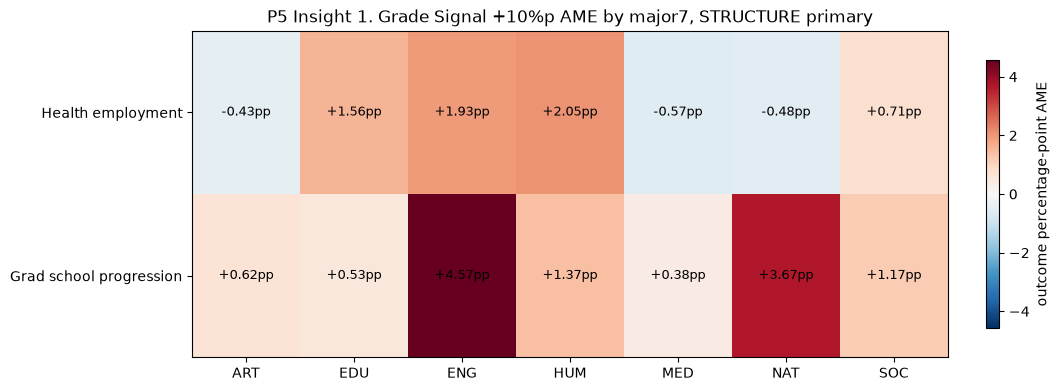

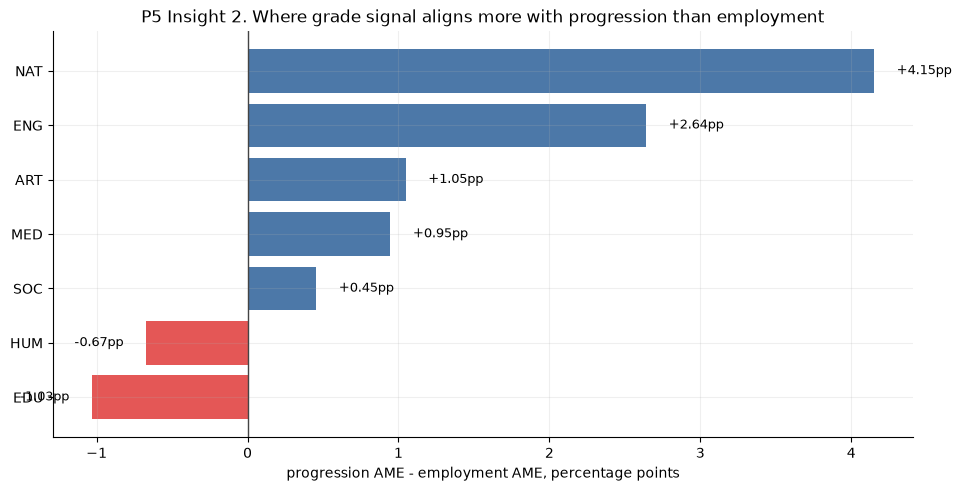

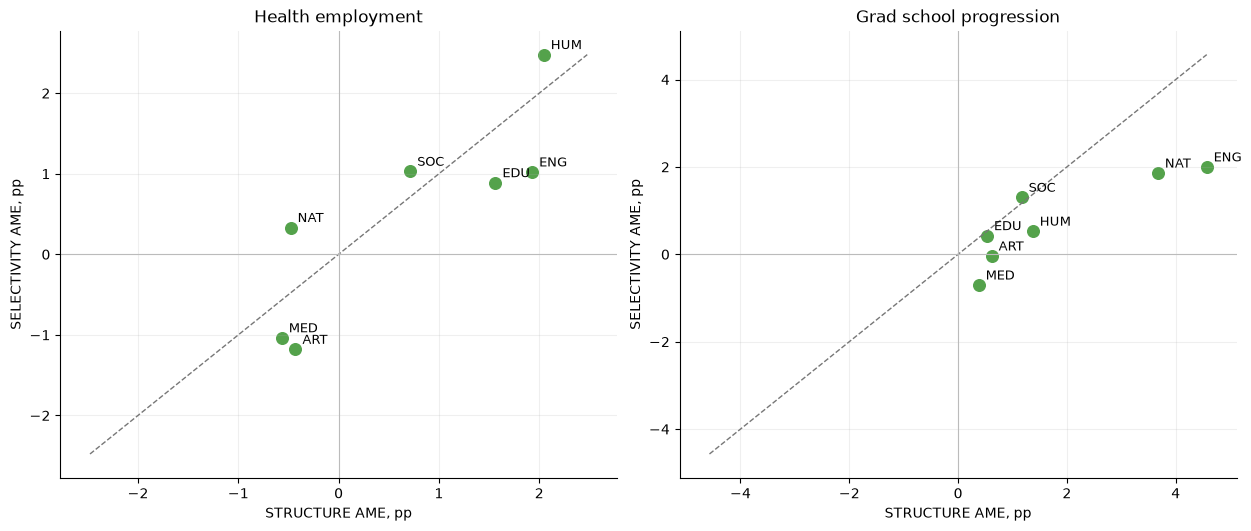

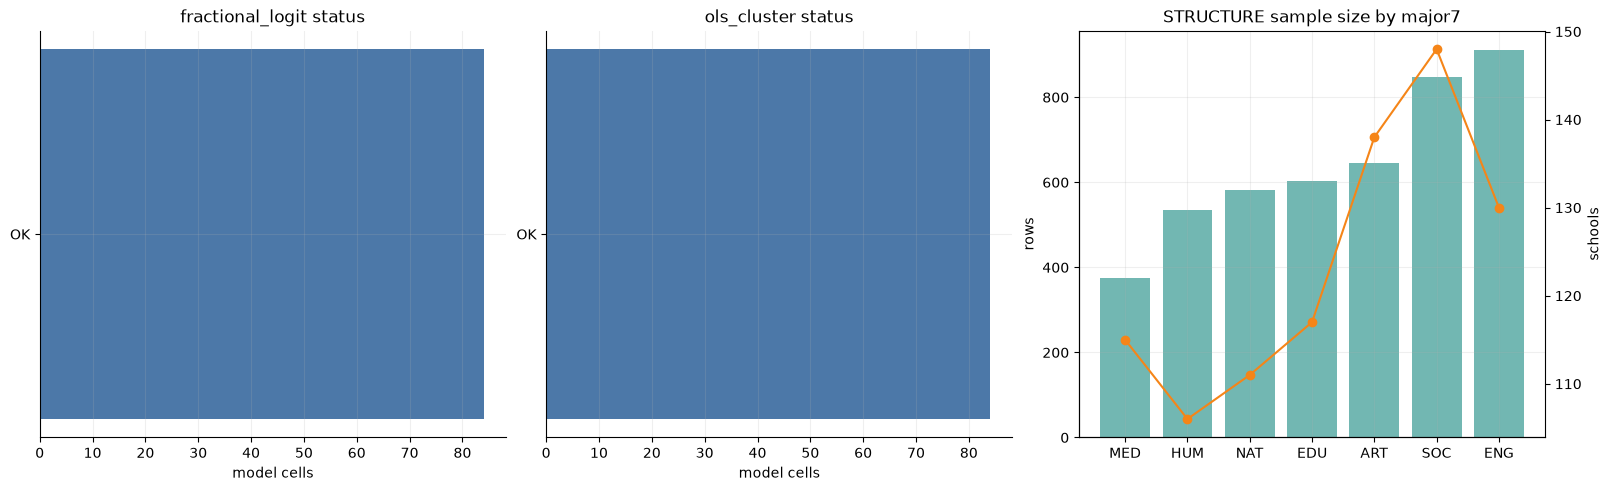

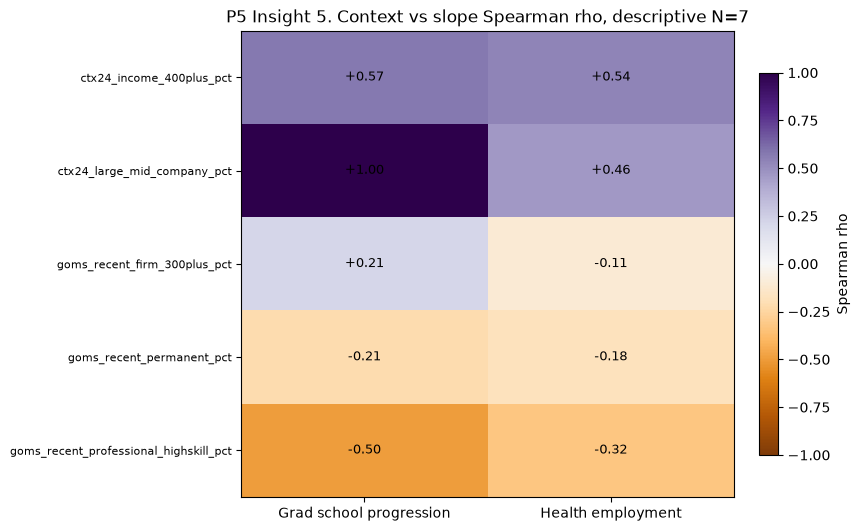

,major_group_7,outcome,outcome_label,grade_signal,ame_10pp,ame_pp,ame_ci_low_10pp,ame_ci_high_10pp,ame_ci_low_pp,ame_ci_high_pp,ci_crosses_zero,direction,row_n,school_n,status,converged
18,MED,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.003801,0.380108,-0.000593,0.073071,-0.059264,7.307119,True,positive,374,115,OK,True
6,EDU,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.005316,0.531553,0.001640,0.012117,0.164020,1.211736,False,positive,602,117,OK,True
2,ART,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.006174,0.617426,0.000515,0.016800,0.051498,1.680044,False,positive,646,138,OK,True
26,SOC,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.011690,1.169029,0.005174,0.023299,0.517430,2.329865,False,positive,848,148,OK,True
14,HUM,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.013732,1.373239,0.004090,0.031646,0.409041,3.164572,False,positive,535,106,OK,True
22,NAT,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.036730,3.673025,0.011689,0.069876,1.168945,6.987563,False,positive,583,111,OK,True
10,ENG,GRAD_SCHOOL_PROGRESSION,Grad school progression,RAW_A,0.045698,4.569829,0.016228,0.091214,1.622846,9.121355,False,positive,911,130,OK,True
19,MED,GRAD_SCHOOL_PROGRESSION,Grad school progression,WITHIN_MAJOR_A,0.003801,0.380108,-0.004291,0.019195,-0.429106,1.919453,True,positive,374,115,OK,True
7,EDU,GRAD_SCHOOL_PROGRESSION,Grad school progression,WITHIN_MAJOR_A,0.005316,0.531553,0.002340,0.008981,0.234031,0.898099,False,positive,602,117,OK,True
3,ART,GRAD_SCHOOL_PROGRESSION,Grad school progression,WITHIN_MAJOR_A,0.006174,0.617426,0.000735,0.012377,0.073464,1.237661,False,positive,646,138,OK,True


,outcome,compared_cells,sign_agreement_cells,ci_overlap_cells,median_abs_diff_pp,max_abs_diff_pp
0,GRAD_SCHOOL_PROGRESSION,7,5,6,0.845268,2.570672
1,HEALTH_EMPLOYMENT,7,6,7,0.675343,0.907791


# P5 Modeling Insight Notes

## AME 단위
모든 AME는 Grade Signal이 10%p 높아질 때 outcome이 몇 percentage point 달라지는지로 읽는다.

## 핵심 관찰
- 대학원 진학률 AME가 가장 큰 계열은 `ENG`이며 RAW_A +10%p당 `+4.57pp`다.
- 건강보험 취업률 AME가 가장 큰 계열은 `HUM`이며 RAW_A +10%p당 `+2.05pp`다.
- 취업률 쪽에서는 음의 AME가 관찰되는 계열이 있다: `MED`(-0.57pp), `NAT`(-0.48pp).
- `진학 AME - 취업 AME`가 가장 큰 계열은 `NAT`이며 `+4.15pp`다.
- 반대로 취업 쪽으로 더 기울어진 계열은 `EDU`이며 차이는 `-1.03pp`다.
- RAW_A와 WITHIN_MAJOR_A의 AME 차이는 최대 `4.248e-15`로, 현재 모델 grid에서는 사실상 같은 기울기를 낸다.

## 해석 제한
- 이 분석은 전공계열별 조건부 기울기 비교이며 인과효과 주장이 아니다.
- context rho heatmap은 N=7 전공계열 점의 기술 통계다. context 효과 검정으로 읽지 않는다.
- 모든 모델 cell에 sparse-level 진단이 붙어 있으므로 계열별 희소 범주와 신뢰구간을 함께 확인해야 한다.

insight figures
workbook/p2/p2_5/p5_major7_heterogeneity_v1/artifacts/P5_INSIGHT_SUMMARY.csv
workbook/p2/p2_5/p5_major7_heterogeneity_v1/artifacts/P5_SIGNAL_EQUIVALENCE_AUDIT.csv
workbook/p2/p2_5/p5_major7_heterogeneity_v1/reports/P5_MODELING_VISUAL_INSIGHT_NOTES.md
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_INSIGHT_AME_HEATMAP_STRUCTURE_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_INSIGHT_PROGRESSION_MINUS_EMPLOYMENT_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_INSIGHT_STRUCTURE_SELECTIVITY_STABILITY_RAW_A.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_INSIGHT_MODEL_DIAGNOSTIC_DASHBOARD.png
workbook/p2/p2_5/p5_major7_heterogeneity_v1/figures/P5_INSIGHT_CONTEXT_RHO_HEATMAP_RAW_A.png


In [29]:
OUTCOME_LABELS = {
    "HEALTH_EMPLOYMENT": "Health employment",
    "GRAD_SCHOOL_PROGRESSION": "Grad school progression",
}
from IPython.display import Markdown

def _display_path(path: Path) -> str:
    return str(path.relative_to(PROJECT_ROOT))

def _clean_axis(ax):
    ax.grid(alpha=0.20)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

insight_primary = structure_primary.query(
    "model_family == 'fractional_logit' and branch == 'STRUCTURE' and control_set == 'B_CORE'"
).copy()
insight_primary["ame_pp"] = insight_primary["ame_10pp"] * 100
insight_primary["ame_ci_low_pp"] = insight_primary["ame_ci_low_10pp"] * 100
insight_primary["ame_ci_high_pp"] = insight_primary["ame_ci_high_10pp"] * 100
insight_primary["ci_crosses_zero"] = (
    insight_primary["ame_ci_low_10pp"].le(0) & insight_primary["ame_ci_high_10pp"].ge(0)
)
insight_primary["direction"] = np.select(
    [insight_primary["ame_10pp"] > 0, insight_primary["ame_10pp"] < 0],
    ["positive", "negative"],
    default="near_zero",
)
insight_primary["outcome_label"] = insight_primary["outcome"].map(OUTCOME_LABELS).fillna(insight_primary["outcome"])

signal_equiv_rows = []
for branch, control_set in [("STRUCTURE", "B_CORE"), ("SELECTIVITY", "B_CORE_B_SCALE_Q")]:
    sub = primary_fractional.query(
        "branch == @branch and control_set == @control_set and model_family == 'fractional_logit'"
    ).copy()
    pivot = sub.pivot_table(
        index=["major_group_7", "outcome"],
        columns="grade_signal",
        values="ame_10pp",
        aggfunc="first",
    )
    if {"RAW_A", "WITHIN_MAJOR_A"}.issubset(pivot.columns):
        diff = (pivot["RAW_A"] - pivot["WITHIN_MAJOR_A"]).abs()
        signal_equiv_rows.append(
            {
                "branch": branch,
                "control_set": control_set,
                "compared_cells": int(diff.notna().sum()),
                "max_abs_ame_difference": float(diff.max()),
                "median_abs_ame_difference": float(diff.median()),
                "equivalent_within_tolerance_1e_10": bool((diff.dropna() < 1e-10).all()),
                "interpretation": (
                    "RAW_A and WITHIN_MAJOR_A have numerically identical AME in this branch; "
                    "use one signal for visual ranking and keep both in audit tables."
                ),
            }
        )

df_signal_equivalence_audit = pd.DataFrame(signal_equiv_rows)
display(df_signal_equivalence_audit)
df_signal_equivalence_audit.to_csv(ARTIFACTS_DIR / "P5_SIGNAL_EQUIVALENCE_AUDIT.csv", index=False)

# 1) AME heatmap: outcome x major for the non-duplicated RAW_A view.
heat_df = insight_primary.query("grade_signal == 'RAW_A'").pivot_table(
    index="outcome_label",
    columns="major_group_7",
    values="ame_pp",
    aggfunc="first",
)
heat_df = heat_df.reindex([OUTCOME_LABELS["HEALTH_EMPLOYMENT"], OUTCOME_LABELS["GRAD_SCHOOL_PROGRESSION"]])
heat_values = heat_df.to_numpy(dtype=float)
vmax = np.nanmax(np.abs(heat_values)) if np.isfinite(heat_values).any() else 1.0
vmax = max(vmax, 0.1)

fig, ax = plt.subplots(figsize=(10.5, 3.8), constrained_layout=True)
im = ax.imshow(heat_values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns)
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title("P5 Insight 1. Grade Signal +10%p AME by major7, STRUCTURE primary")
for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        value = heat_values[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:+.2f}pp", ha="center", va="center", fontsize=9)
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("outcome percentage-point AME")
heatmap_path = FIGURES_DIR / "P5_INSIGHT_AME_HEATMAP_STRUCTURE_RAW_A.png"
fig.savefig(heatmap_path, dpi=180)
plt.show()
plt.close(fig)

# 2) Outcome contrast: progression AME minus employment AME.
trade_df = df_employment_progression_diff.query(
    "branch == 'STRUCTURE' and control_set == 'B_CORE' and grade_signal == 'RAW_A'"
).copy()
trade_df["difference_pp"] = trade_df["difference"] * 100
trade_df = trade_df.sort_values("difference_pp")

fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
colors = np.where(trade_df["difference_pp"] >= 0, "#4C78A8", "#E45756")
ax.barh(trade_df["major_group_7"], trade_df["difference_pp"], color=colors)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_xlabel("progression AME - employment AME, percentage points")
ax.set_title("P5 Insight 2. Where grade signal aligns more with progression than employment")
_clean_axis(ax)
for y, value in enumerate(trade_df["difference_pp"]):
    ha = "left" if value >= 0 else "right"
    x = value + (0.15 if value >= 0 else -0.15)
    ax.text(x, y, f"{value:+.2f}pp", va="center", ha=ha, fontsize=9)
tradeoff_path = FIGURES_DIR / "P5_INSIGHT_PROGRESSION_MINUS_EMPLOYMENT_RAW_A.png"
fig.savefig(tradeoff_path, dpi=180)
plt.show()
plt.close(fig)

# 3) Structure vs selectivity stability.
stability_plot = df_structure_selectivity_stability.query("grade_signal == 'RAW_A'").copy()
stability_plot["structure_pp"] = stability_plot["ame_10pp_structure"] * 100
stability_plot["selectivity_pp"] = stability_plot["ame_10pp_selectivity"] * 100
outcomes = [key for key in OUTCOME_SPECS if key in set(stability_plot["outcome"])]
fig, axes = plt.subplots(1, len(outcomes), figsize=(6.2 * len(outcomes), 5.2), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, outcome_key in zip(axes, outcomes):
    sub = stability_plot.query("outcome == @outcome_key").copy()
    lim = np.nanmax(np.abs(sub[["structure_pp", "selectivity_pp"]].to_numpy(dtype=float)))
    lim = max(lim, 0.5)
    ax.scatter(sub["structure_pp"], sub["selectivity_pp"], s=70, color="#54A24B")
    for _, point in sub.iterrows():
        ax.annotate(
            str(point["major_group_7"]),
            (point["structure_pp"], point["selectivity_pp"]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=9,
        )
    ax.plot([-lim, lim], [-lim, lim], color="#777777", linewidth=1, linestyle="--")
    ax.axhline(0, color="#BBBBBB", linewidth=0.8)
    ax.axvline(0, color="#BBBBBB", linewidth=0.8)
    ax.set_xlim(-lim * 1.12, lim * 1.12)
    ax.set_ylim(-lim * 1.12, lim * 1.12)
    ax.set_xlabel("STRUCTURE AME, pp")
    ax.set_ylabel("SELECTIVITY AME, pp")
    ax.set_title(OUTCOME_LABELS.get(outcome_key, outcome_key))
    _clean_axis(ax)
stability_path = FIGURES_DIR / "P5_INSIGHT_STRUCTURE_SELECTIVITY_STABILITY_RAW_A.png"
fig.savefig(stability_path, dpi=180)
plt.show()
plt.close(fig)

# 4) Model diagnostic dashboard.
status_counts = df_slope_estimates.groupby(["model_family", "status"]).size().rename("model_count").reset_index()
row_school = insight_primary.query("grade_signal == 'RAW_A' and outcome == 'HEALTH_EMPLOYMENT'").copy()
row_school = row_school.sort_values("row_n")
flag_counts = (
    df_model_diagnostics["diagnostic_flag"].fillna("").replace("", "none")
    .value_counts()
    .rename_axis("diagnostic_flag")
    .reset_index(name="row_n")
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
for ax, (family, sub) in zip(axes[:2], status_counts.groupby("model_family")):
    sub = sub.sort_values("model_count")
    ax.barh(sub["status"], sub["model_count"], color="#4C78A8")
    ax.set_title(f"{family} status")
    ax.set_xlabel("model cells")
    _clean_axis(ax)
ax = axes[2]
ax.bar(row_school["major_group_7"], row_school["row_n"], color="#72B7B2", label="rows")
ax2 = ax.twinx()
ax2.plot(row_school["major_group_7"], row_school["school_n"], color="#F58518", marker="o", label="schools")
ax.set_title("STRUCTURE sample size by major7")
ax.set_ylabel("rows")
ax2.set_ylabel("schools")
ax.tick_params(axis="x", rotation=0)
_clean_axis(ax)
diagnostic_path = FIGURES_DIR / "P5_INSIGHT_MODEL_DIAGNOSTIC_DASHBOARD.png"
fig.savefig(diagnostic_path, dpi=180)
plt.show()
plt.close(fig)

# 5) Context rho heatmap. This is descriptive only, because n_major = 7.
context_rho = df_slope_context_descriptive.query("grade_signal == 'RAW_A'").copy()
context_rho["outcome_label"] = context_rho["outcome"].map(OUTCOME_LABELS).fillna(context_rho["outcome"])
rho_heat = context_rho.pivot_table(
    index="context_column",
    columns="outcome_label",
    values="spearman_rho",
    aggfunc="first",
)
if not rho_heat.empty:
    fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
    values = rho_heat.to_numpy(dtype=float)
    im = ax.imshow(values, cmap="PuOr", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(len(rho_heat.columns)))
    ax.set_xticklabels(rho_heat.columns)
    ax.set_yticks(np.arange(len(rho_heat.index)))
    ax.set_yticklabels(rho_heat.index, fontsize=8)
    ax.set_title("P5 Insight 5. Context vs slope Spearman rho, descriptive N=7")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=9)
    cbar = fig.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label("Spearman rho")
    context_rho_path = FIGURES_DIR / "P5_INSIGHT_CONTEXT_RHO_HEATMAP_RAW_A.png"
    fig.savefig(context_rho_path, dpi=180)
    plt.show()
    plt.close(fig)
else:
    context_rho_path = None

insight_summary = insight_primary[
    [
        "major_group_7",
        "outcome",
        "outcome_label",
        "grade_signal",
        "ame_10pp",
        "ame_pp",
        "ame_ci_low_10pp",
        "ame_ci_high_10pp",
        "ame_ci_low_pp",
        "ame_ci_high_pp",
        "ci_crosses_zero",
        "direction",
        "row_n",
        "school_n",
        "status",
        "converged",
    ]
].sort_values(["outcome", "grade_signal", "ame_10pp"])
insight_summary.to_csv(ARTIFACTS_DIR / "P5_INSIGHT_SUMMARY.csv", index=False)

top_progression = insight_summary.query("grade_signal == 'RAW_A' and outcome == 'GRAD_SCHOOL_PROGRESSION'").sort_values("ame_pp", ascending=False).head(1)
top_employment = insight_summary.query("grade_signal == 'RAW_A' and outcome == 'HEALTH_EMPLOYMENT'").sort_values("ame_pp", ascending=False).head(1)
bottom_employment = insight_summary.query("grade_signal == 'RAW_A' and outcome == 'HEALTH_EMPLOYMENT'").sort_values("ame_pp").head(2)
top_tradeoff = trade_df.sort_values("difference_pp", ascending=False).head(1)
bottom_tradeoff = trade_df.sort_values("difference_pp").head(1)
stability_summary = stability_plot.groupby("outcome").agg(
    compared_cells=("major_group_7", "count"),
    sign_agreement_cells=("sign_agreement", "sum"),
    ci_overlap_cells=("ci_overlap", "sum"),
    median_abs_diff_pp=("absolute_difference", lambda s: float(np.nanmedian(s) * 100)),
    max_abs_diff_pp=("absolute_difference", lambda s: float(np.nanmax(s) * 100)),
).reset_index()
display(insight_summary)
display(stability_summary)

lines = [
    "# P5 Modeling Insight Notes",
    "",
    "## AME 단위",
    "모든 AME는 Grade Signal이 10%p 높아질 때 outcome이 몇 percentage point 달라지는지로 읽는다.",
    "",
    "## 핵심 관찰",
]
if len(top_progression):
    row = top_progression.iloc[0]
    lines.append(f"- 대학원 진학률 AME가 가장 큰 계열은 `{row['major_group_7']}`이며 RAW_A +10%p당 `{row['ame_pp']:+.2f}pp`다.")
if len(top_employment):
    row = top_employment.iloc[0]
    lines.append(f"- 건강보험 취업률 AME가 가장 큰 계열은 `{row['major_group_7']}`이며 RAW_A +10%p당 `{row['ame_pp']:+.2f}pp`다.")
if len(bottom_employment):
    majors = ", ".join(f"`{r.major_group_7}`({r.ame_pp:+.2f}pp)" for r in bottom_employment.itertuples())
    lines.append(f"- 취업률 쪽에서는 음의 AME가 관찰되는 계열이 있다: {majors}.")
if len(top_tradeoff):
    row = top_tradeoff.iloc[0]
    lines.append(f"- `진학 AME - 취업 AME`가 가장 큰 계열은 `{row['major_group_7']}`이며 `{row['difference_pp']:+.2f}pp`다.")
if len(bottom_tradeoff):
    row = bottom_tradeoff.iloc[0]
    lines.append(f"- 반대로 취업 쪽으로 더 기울어진 계열은 `{row['major_group_7']}`이며 차이는 `{row['difference_pp']:+.2f}pp`다.")
if len(df_signal_equivalence_audit):
    max_diff = df_signal_equivalence_audit["max_abs_ame_difference"].max()
    lines.append(f"- RAW_A와 WITHIN_MAJOR_A의 AME 차이는 최대 `{max_diff:.3e}`로, 현재 모델 grid에서는 사실상 같은 기울기를 낸다.")
lines += [
    "",
    "## 해석 제한",
    "- 이 분석은 전공계열별 조건부 기울기 비교이며 인과효과 주장이 아니다.",
    "- context rho heatmap은 N=7 전공계열 점의 기술 통계다. context 효과 검정으로 읽지 않는다.",
    "- 모든 모델 cell에 sparse-level 진단이 붙어 있으므로 계열별 희소 범주와 신뢰구간을 함께 확인해야 한다.",
]
insight_note_path = REPORTS_DIR / "P5_MODELING_VISUAL_INSIGHT_NOTES.md"
insight_note_path.write_text("\n".join(lines), encoding="utf-8")
display(Markdown("\n".join(lines)))

insight_required_outputs = [
    ARTIFACTS_DIR / "P5_INSIGHT_SUMMARY.csv",
    ARTIFACTS_DIR / "P5_SIGNAL_EQUIVALENCE_AUDIT.csv",
    REPORTS_DIR / "P5_MODELING_VISUAL_INSIGHT_NOTES.md",
    heatmap_path,
    tradeoff_path,
    stability_path,
    diagnostic_path,
]
if context_rho_path is not None:
    insight_required_outputs.append(context_rho_path)
print("insight figures")
for path in insight_required_outputs:
    print(_display_path(path))

In [30]:
interpretation_rows = []
for _, row in structure_primary.query("model_family == 'fractional_logit' and status in ['OK', 'WARN_RANK_DEFICIENT', 'WARN_NOT_CONVERGED']").iterrows():
    direction = "양의" if row["ame_10pp"] > 0 else "음의" if row["ame_10pp"] < 0 else "0에 가까운"
    interpretation_rows.append(
        {
            "major_group_7": row["major_group_7"],
            "outcome": row["outcome"],
            "grade_signal": row["grade_signal"],
            "allowed_sentence": (
                f"{row['major_group_7']} 계열에서는 {row['grade_signal']}과 "
                f"{row['outcome']} 사이에 {direction} 조건부 기울기가 관찰됐다."
            ),
            "guardrail": "탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.",
        }
    )
df_interpretation_guardrails = pd.DataFrame(interpretation_rows)
display(df_interpretation_guardrails.head(20))
df_interpretation_guardrails.to_csv(REPORTS_DIR / "P5_INTERPRETATION_GUARDRAILS.csv", index=False)

,major_group_7,outcome,grade_signal,allowed_sentence,guardrail
0,ART,HEALTH_EMPLOYMENT,RAW_A,ART 계열에서는 RAW_A과 HEALTH_EMPLOYMENT 사이에 음의 조건부 ...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
1,ART,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,ART 계열에서는 WITHIN_MAJOR_A과 HEALTH_EMPLOYMENT 사이...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
2,ART,GRAD_SCHOOL_PROGRESSION,RAW_A,ART 계열에서는 RAW_A과 GRAD_SCHOOL_PROGRESSION 사이에 양...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
3,ART,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,ART 계열에서는 WITHIN_MAJOR_A과 GRAD_SCHOOL_PROGRESS...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
4,EDU,HEALTH_EMPLOYMENT,RAW_A,EDU 계열에서는 RAW_A과 HEALTH_EMPLOYMENT 사이에 양의 조건부 ...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
5,EDU,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,EDU 계열에서는 WITHIN_MAJOR_A과 HEALTH_EMPLOYMENT 사이...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
6,EDU,GRAD_SCHOOL_PROGRESSION,RAW_A,EDU 계열에서는 RAW_A과 GRAD_SCHOOL_PROGRESSION 사이에 양...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
7,EDU,GRAD_SCHOOL_PROGRESSION,WITHIN_MAJOR_A,EDU 계열에서는 WITHIN_MAJOR_A과 GRAD_SCHOOL_PROGRESS...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
8,ENG,HEALTH_EMPLOYMENT,RAW_A,ENG 계열에서는 RAW_A과 HEALTH_EMPLOYMENT 사이에 양의 조건부 ...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.
9,ENG,HEALTH_EMPLOYMENT,WITHIN_MAJOR_A,ENG 계열에서는 WITHIN_MAJOR_A과 HEALTH_EMPLOYMENT 사이...,탐색적 조건부 기울기이며 인과효과 또는 context 효과로 해석하지 않는다.


In [31]:
panel_files = {
    "mart_department_panel_2023_2025.parquet": [
        PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/data/mart_department_panel_2023_2025.parquet",
    ],
    "mart_major7_context_2023_2025.parquet": [
        PROJECT_ROOT / "workbook/p2/p2_4/p4_modeling_readiness_v4/data/mart_major7_context_2023_2025.parquet",
    ],
}
panel_gate_rows = []
for logical_name, candidates in panel_files.items():
    existing = [p for p in candidates if p.exists()]
    panel_gate_rows.append(
        {
            "logical_name": logical_name,
            "exists": bool(existing),
            "path": str(existing[0].relative_to(PROJECT_ROOT)) if existing else None,
        }
    )
df_panel_gate = pd.DataFrame(panel_gate_rows)
P5_MAJOR7_YEAR_STATUS = "READY" if df_panel_gate["exists"].all() else "NOT_AVAILABLE"
display(df_panel_gate)
df_panel_gate.to_csv(QA_DIR / "P5_MAJOR7_YEAR_PANEL_GATE.csv", index=False)
print("P5_MAJOR7_YEAR_STATUS =", P5_MAJOR7_YEAR_STATUS)

,logical_name,exists,path
0,mart_department_panel_2023_2025.parquet,False,None
1,mart_major7_context_2023_2025.parquet,False,None


P5_MAJOR7_YEAR_STATUS = NOT_AVAILABLE


In [32]:
save_dataframe(df_p5_structure, DATA_DIR / "P5_STRUCTURE_ANALYSIS_FRAME.parquet")
save_dataframe(df_p5_selectivity, DATA_DIR / "P5_SELECTIVITY_ANALYSIS_FRAME.parquet")

required_outputs = [
    ARTIFACTS_DIR / "P5_MODEL_SPEC_REGISTRY.csv",
    ARTIFACTS_DIR / "P5_MAJOR7_SLOPE_ESTIMATES.csv",
    ARTIFACTS_DIR / "P5_MAJOR7_CONTEXT_PROFILE.csv",
    ARTIFACTS_DIR / "P5_SLOPE_CONTEXT_DESCRIPTIVE.csv",
    DATA_DIR / "P5_STRUCTURE_ANALYSIS_FRAME.parquet",
    DATA_DIR / "P5_SELECTIVITY_ANALYSIS_FRAME.parquet",
    QA_DIR / "P5_CELL_ELIGIBILITY.csv",
    QA_DIR / "P5_MODEL_DIAGNOSTICS.csv",
    QA_DIR / "P5_STRUCTURE_SELECTIVITY_STABILITY.csv",
]
if "insight_required_outputs" in globals():
    required_outputs.extend(insight_required_outputs)

employment_summary = (
    structure_primary.query("outcome == 'HEALTH_EMPLOYMENT'")
    .groupby("grade_signal")
    .agg(
        cells=("ame_10pp", "count"),
        positive=("ame_10pp", lambda s: int((s > 0).sum())),
        negative=("ame_10pp", lambda s: int((s < 0).sum())),
        median_ame=("ame_10pp", "median"),
    )
    .reset_index()
)
progression_summary = (
    structure_primary.query("outcome == 'GRAD_SCHOOL_PROGRESSION'")
    .groupby("grade_signal")
    .agg(
        cells=("ame_10pp", "count"),
        positive=("ame_10pp", lambda s: int((s > 0).sum())),
        negative=("ame_10pp", lambda s: int((s < 0).sum())),
        median_ame=("ame_10pp", "median"),
    )
    .reset_index()
)
stability_summary = df_structure_selectivity_stability.groupby(["outcome", "grade_signal"]).agg(
    compared_cells=("major_group_7", "count"),
    sign_agreement_cells=("sign_agreement", "sum"),
    ci_overlap_cells=("ci_overlap", "sum"),
).reset_index()

def _markdown_table(obj) -> str:
    if isinstance(obj, pd.Series):
        frame = obj.reset_index()
    else:
        frame = obj.copy()
    if frame.empty:
        return "_empty_"
    frame = frame.astype(object).where(pd.notna(frame), "")
    columns = [str(col) for col in frame.columns]
    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for _, record in frame.iterrows():
        values = [str(record[col]).replace("|", "/") for col in frame.columns]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)

report_lines = [
    "# P5 2024 Major7 Grade-Signal Heterogeneity Report",
    "",
    "## 1. 연구질문",
    "같은 전공계열 안에서 학과별 A비율 또는 조건부 A비율 편차가 건강보험 취업률 및 대학원 진학률과 어떤 관계를 가지며, 그 관계의 기울기가 7개 전공계열 사이에서 어떻게 다른지 탐색했다.",
    "",
    "## 2. 데이터와 표본",
    f"- D08: `{INPUTS['d08_model_base']['path'].relative_to(PROJECT_ROOT)}`",
    f"- D08 SHA256: `{EXPECTED_D08_SHA256}`",
    f"- Structure sample: N={len(df_p5_structure):,}, school_n={df_p5_structure['school_uid'].nunique():,}",
    f"- Selectivity sample: N={len(df_p5_selectivity):,}, school_n={df_p5_selectivity['school_uid'].nunique():,}",
    "",
    "## 3. Grade Signal 정의",
    "- RAW_A: `a_rate_pct / 10`",
    "- WITHIN_MAJOR_A: 같은 `major_group_7 × analysis_year` 평균에서 벗어난 A비율 편차 / 10",
    "- OOF_RESIDUAL: P3 manifest가 제공될 때만 실행한다.",
    "",
    "## 4. 계열별 cell eligibility",
    _markdown_table(df_cell_eligibility.groupby(["branch", "outcome", "grade_signal"])["estimable"].sum().rename("estimable_major_count")),
    "",
    "## 5. 건강보험 취업 기울기",
    _markdown_table(employment_summary),
    "",
    "## 6. 대학원 진학 기울기",
    _markdown_table(progression_summary),
    "",
    "## 7. 취업·진학 차이",
    "계열별 `AME_progression - AME_employment`는 `artifacts/P5_EMPLOYMENT_PROGRESSION_AME_DIFFERENCE.csv`에 저장했다. 이 차이는 탐색적 비교이며 확증적 검정 결론으로 사용하지 않는다.",
    "",
    "## 8. 구조분기·입결분기 안정성",
    _markdown_table(stability_summary),
    "",
    "## 9. 노동시장 context 기술 비교",
    "Context는 `major_group_7` grain에서만 slope table과 결합했다. N=7 점 산점도와 Spearman rho는 기술적 참고값이며 context 효과를 주장하지 않는다.",
    "",
    "## 10. 한계와 금지해석",
    "- Fractional logit은 fractional response quasi-likelihood로 사용했다.",
    "- 학과 단위 관측을 개인 Bernoulli 시행으로 해석하지 않는다.",
    "- 특정 계열 context가 Grade Signal 효과를 높였다고 해석하지 않는다.",
    "- 특정 학과 졸업생의 대기업 취업률이 높다는 식의 개인/학과 단정으로 확장하지 않는다.",
    "",
    "## 11. P3 residual 대기 여부",
    f"`P5_RESIDUAL_BRANCH_STATUS = {P5_RESIDUAL_BRANCH_STATUS}`",
    "",
    "## 12. 미래 major7×year 확장 상태",
    f"`P5_MAJOR7_YEAR_STATUS = {P5_MAJOR7_YEAR_STATUS}`",
    "",
]

report_path = REPORTS_DIR / "P5_2024_MAJOR7_HETEROGENEITY_REPORT.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

P5_STRUCTURE_STATUS = "READY"
P5_SELECTIVITY_STATUS = "READY"
P5_RAW_A_STATUS = "READY" if "RAW_A" in set(df_slope_estimates["grade_signal"]) else "NOT_AVAILABLE"
P5_WITHIN_A_STATUS = "READY" if "WITHIN_MAJOR_A" in set(df_slope_estimates["grade_signal"]) else "NOT_AVAILABLE"
P5_RESIDUAL_STATUS = P5_RESIDUAL_BRANCH_STATUS
model_failed_n = int((df_slope_estimates["status"] == "MODEL_FAILED").sum())
warn_n = int(df_model_diagnostics["diagnostic_flag"].fillna("").ne("").sum())
P5_OVERALL_STATUS = "READY_WITH_WARNINGS" if warn_n or P5_RESIDUAL_STATUS.startswith("PENDING") else "READY"
if model_failed_n:
    P5_OVERALL_STATUS = "READY_WITH_WARNINGS"

estimable_cell_payload = {
    " | ".join(map(str, key if isinstance(key, tuple) else (key,))): int(value)
    for key, value in df_cell_eligibility.groupby(["branch", "outcome", "grade_signal"])["estimable"].sum().items()
}

status_payload = {
    **EXECUTION_CONTEXT,
    "P5_STRUCTURE_STATUS": P5_STRUCTURE_STATUS,
    "P5_SELECTIVITY_STATUS": P5_SELECTIVITY_STATUS,
    "P5_RAW_A_STATUS": P5_RAW_A_STATUS,
    "P5_WITHIN_A_STATUS": P5_WITHIN_A_STATUS,
    "P5_RESIDUAL_STATUS": P5_RESIDUAL_STATUS,
    "P5_CONTEXT_PROFILE_STATUS": P5_CONTEXT_PROFILE_STATUS,
    "P5_MAJOR7_YEAR_STATUS": P5_MAJOR7_YEAR_STATUS,
    "P5_OVERALL_STATUS": P5_OVERALL_STATUS,
    "D08_SHA256": EXPECTED_D08_SHA256,
    "structure_sample": structure_audit,
    "selectivity_sample": selectivity_audit,
    "estimable_cells": estimable_cell_payload,
    "model_status_counts": df_slope_estimates["status"].value_counts(dropna=False).to_dict(),
    "fail_warn": {
        "model_failed_n": model_failed_n,
        "diagnostic_rows_with_flags": warn_n,
        "residual_branch": P5_RESIDUAL_STATUS,
    },
}

status_path = REPORTS_DIR / "P5_2024_MAJOR7_HETEROGENEITY_STATUS.json"
with status_path.open("w", encoding="utf-8") as handle:
    json.dump(status_payload, handle, ensure_ascii=False, indent=2, default=str)

required_outputs.extend([report_path, status_path])
missing_outputs = [str(p.relative_to(PROJECT_ROOT)) for p in required_outputs if not p.exists()]
if missing_outputs:
    raise RuntimeError(f"Missing required outputs: {missing_outputs}")

print("saved report:", report_path.relative_to(PROJECT_ROOT))
print("required output count:", len(required_outputs))

saved report: workbook/p2/p2_5/p5_major7_heterogeneity_v1/reports/P5_2024_MAJOR7_HETEROGENEITY_REPORT.md
required output count: 19


In [33]:
def _artifact_record(path: Path) -> dict:
    stat = path.stat()
    shape = None
    if path.suffix == ".csv":
        try:
            shape = pd.read_csv(path).shape
        except Exception:
            shape = None
    elif path.suffix == ".parquet":
        try:
            shape = pd.read_parquet(path).shape
        except Exception:
            shape = None
    return {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "shape": shape,
        "size_bytes": int(stat.st_size),
        "sha256": sha256_file(path),
        "mtime": datetime.fromtimestamp(stat.st_mtime, tz=timezone.utc).isoformat(),
    }

manifest_paths = []
for root in [ARTIFACTS_DIR, DATA_DIR, FIGURES_DIR, QA_DIR, REPORTS_DIR]:
    manifest_paths.extend([p for p in root.rglob("*") if p.is_file()])
manifest_paths = sorted(set(manifest_paths))
output_manifest = [_artifact_record(path) for path in manifest_paths]
manifest_path = LOGS_DIR / "P5_OUTPUT_MANIFEST.json"
with manifest_path.open("w", encoding="utf-8") as handle:
    json.dump(output_manifest, handle, ensure_ascii=False, indent=2, default=str)

final_status = {
    "P5_STRUCTURE_STATUS": P5_STRUCTURE_STATUS,
    "P5_SELECTIVITY_STATUS": P5_SELECTIVITY_STATUS,
    "P5_RAW_A_STATUS": P5_RAW_A_STATUS,
    "P5_WITHIN_A_STATUS": P5_WITHIN_A_STATUS,
    "P5_RESIDUAL_STATUS": P5_RESIDUAL_STATUS,
    "P5_CONTEXT_PROFILE_STATUS": P5_CONTEXT_PROFILE_STATUS,
    "P5_MAJOR7_YEAR_STATUS": P5_MAJOR7_YEAR_STATUS,
    "P5_OVERALL_STATUS": P5_OVERALL_STATUS,
}
print(json.dumps(final_status, ensure_ascii=False, indent=2))
print("manifest:", manifest_path.relative_to(PROJECT_ROOT), sha256_file(manifest_path))
display(pd.DataFrame(output_manifest))

{
  "P5_STRUCTURE_STATUS": "READY",
  "P5_SELECTIVITY_STATUS": "READY",
  "P5_RAW_A_STATUS": "READY",
  "P5_WITHIN_A_STATUS": "READY",
  "P5_RESIDUAL_STATUS": "PENDING_UPSTREAM_RESIDUAL",
  "P5_CONTEXT_PROFILE_STATUS": "READY",
  "P5_MAJOR7_YEAR_STATUS": "NOT_AVAILABLE",
  "P5_OVERALL_STATUS": "READY_WITH_WARNINGS"
}
manifest: workbook/p2/p2_5/p5_major7_heterogeneity_v1/logs/P5_OUTPUT_MANIFEST.json 77c12a7a799ac84cf7879f720d24e328e06462a42537b7730c1e4e561d2692c3


,path,shape,size_bytes,sha256,mtime
0,workbook/p2/p2_5/p5_major7_heterogeneity_v1/ar...,"(28, 7)",2918,8f1e06a406951053df31009f1b1f14691d775b00e12891...,2026-07-13T05:23:44.841739+00:00
1,workbook/p2/p2_5/p5_major7_heterogeneity_v1/ar...,"(28, 16)",5988,4360237f0bb7fdef438423767ce70f9d556d7bff55de4e...,2026-07-13T05:23:48.825060+00:00
2,workbook/p2/p2_5/p5_major7_heterogeneity_v1/ar...,"(7, 11)",789,bea057f64d2daff1328374c90c5dfb56a3feca3bacf71a...,2026-07-13T05:23:27.658584+00:00
3,workbook/p2/p2_5/p5_major7_heterogeneity_v1/ar...,"(168, 28)",119223,62e13821b3f3f3e6ac67e074967416cf5d4bd3a9c897ca...,2026-07-13T05:23:44.362882+00:00
4,workbook/p2/p2_5/p5_major7_heterogeneity_v1/ar...,"(12, 13)",5027,9abc8b7ec934ca77d1511e8f33fd5df36e3b9d7467024b...,2026-07-13T05:23:28.414191+00:00
...,...,...,...,...,...
68,workbook/p2/p2_5/p5_major7_heterogeneity_v1/qa...,"(20, 2)",481,93ad22bbfff37ba97cd8dcdbec96b613700687fa0b6eb1...,2026-07-13T05:23:27.381994+00:00
69,workbook/p2/p2_5/p5_major7_heterogeneity_v1/re...,None,3233,13714598e126b4adc25dfb29bd000041db22cccf536fd7...,2026-07-13T05:23:48.980299+00:00
70,workbook/p2/p2_5/p5_major7_heterogeneity_v1/re...,None,2276,404bab330284c3f66fcc9050ededf14dc759854410aae1...,2026-07-13T05:23:48.983082+00:00
71,workbook/p2/p2_5/p5_major7_heterogeneity_v1/re...,"(28, 5)",6838,755bbaf6bc6fc11a193ca5f415b1652675098d2e89f6eb...,2026-07-13T05:23:48.877010+00:00
